1. **Membrane Potential Visualization**
2. **PSTH Metric - Peristimulus Time Histogram Analysis**
3. **PSP Counts Metric - Peak detection in membrane potentials**
4. **Granger Causality Metric**

In [2]:
#Importing necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D
import numpy as np
import os
import h5py
import helper_functions as hp
import data_loading as dl
gt_data, gt_spikes, sub_data, sub_spikes, cfg, tmap, truth_table, h5_file_path_gt, h5_file_path_sub = dl.get_data()


GT Voltage Data Loading done!
GT Spikes Data Loading done!
SUB Voltage Data Loading done!
SUB Spikes Data Loading done!
Network configuration Loading done!
Trial Map Loading done!
Data Loading done!
GT Voltage Data Loading done!
GT Spikes Data Loading done!
SUB Voltage Data Loading done!
SUB Spikes Data Loading done!
Network configuration Loading done!
Trial Map Loading done!


Membrane Potential Visualization - Stitched Traces and Statistical Views
[0, 4, 8, 12, 16, 20, 24, 28, 32, 36]


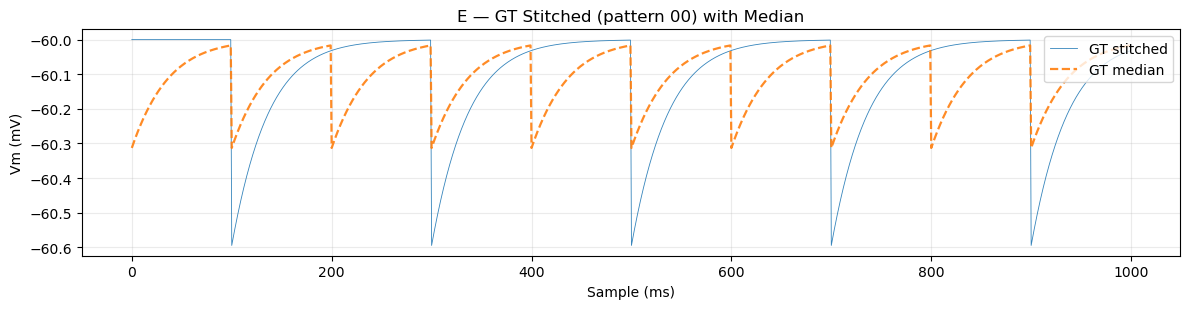

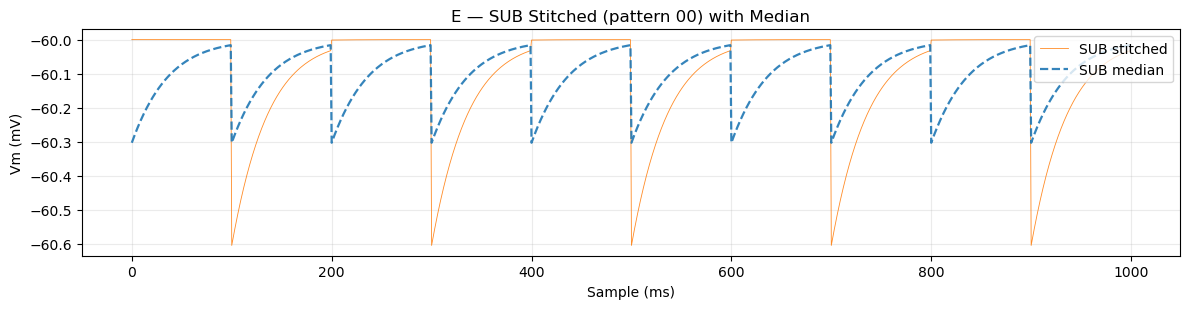

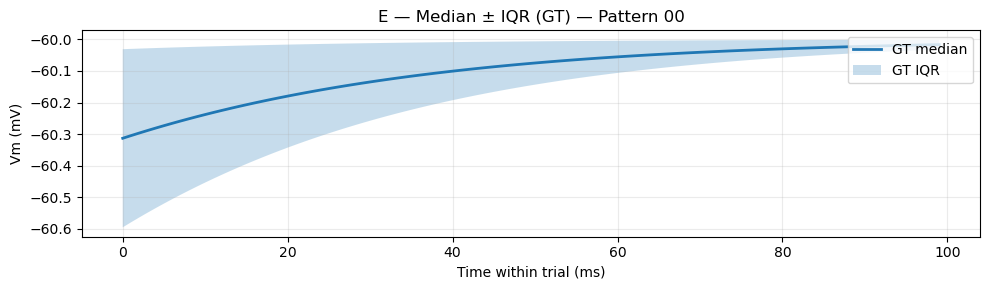

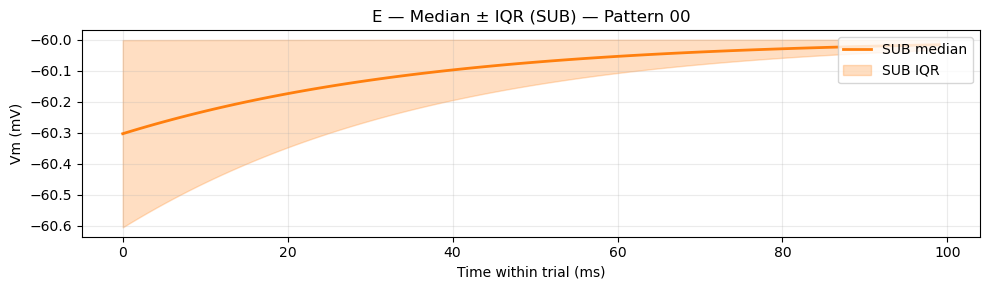

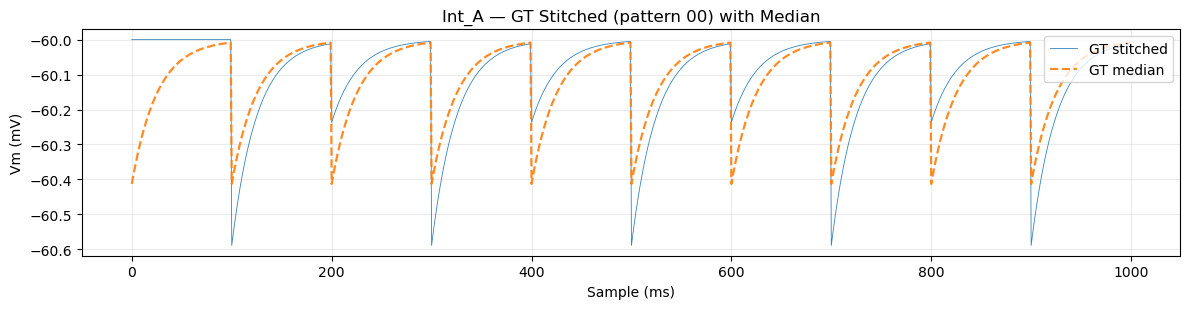

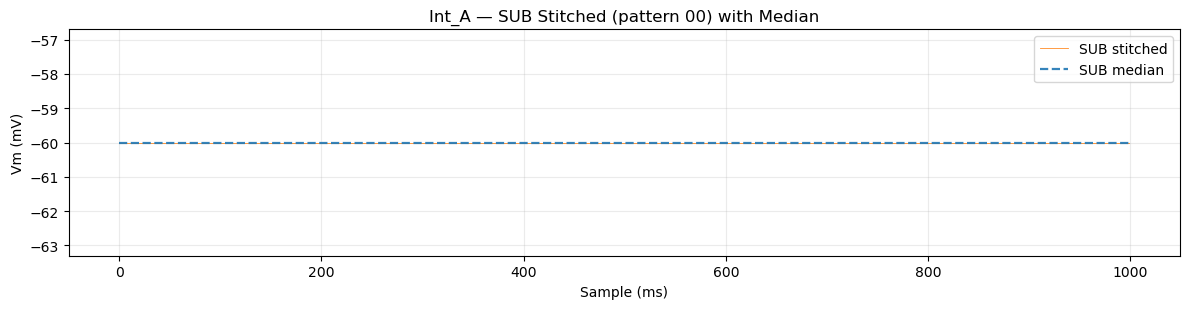

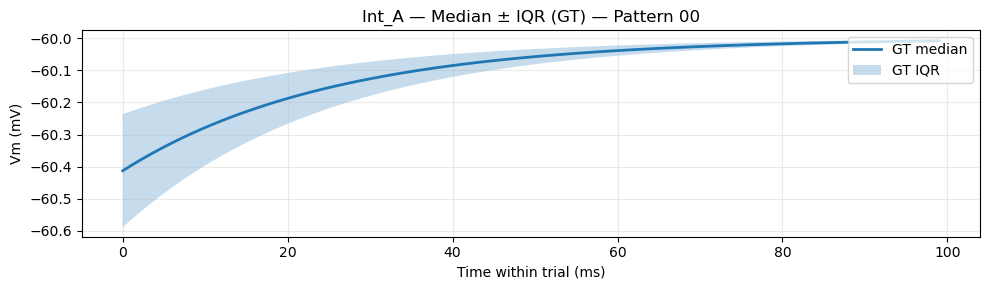

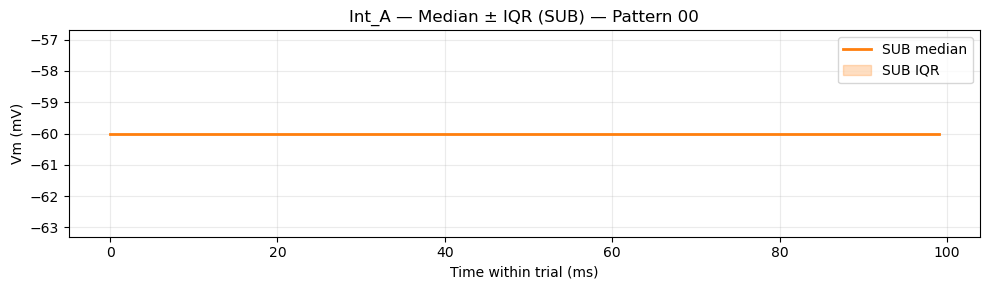

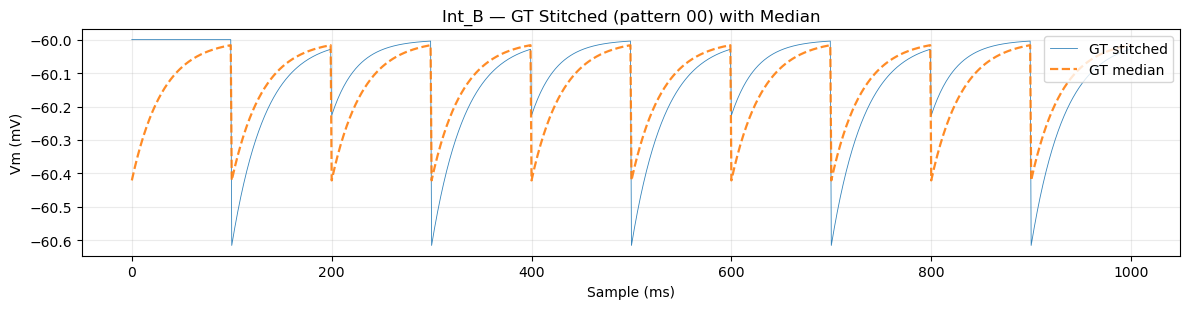

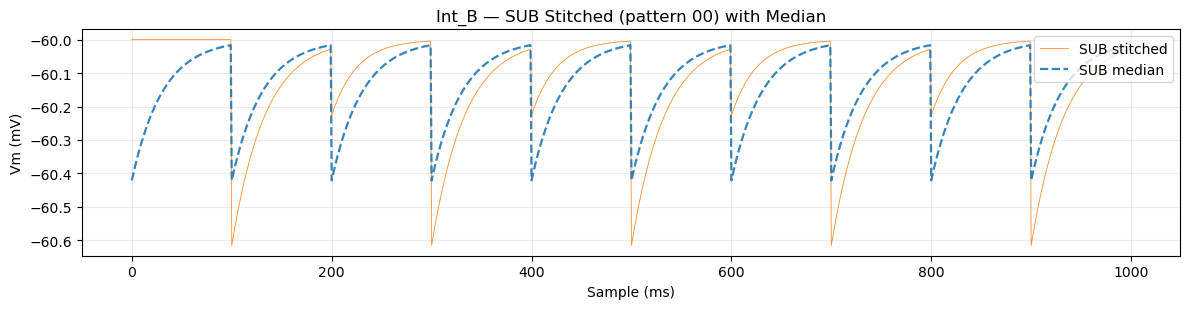

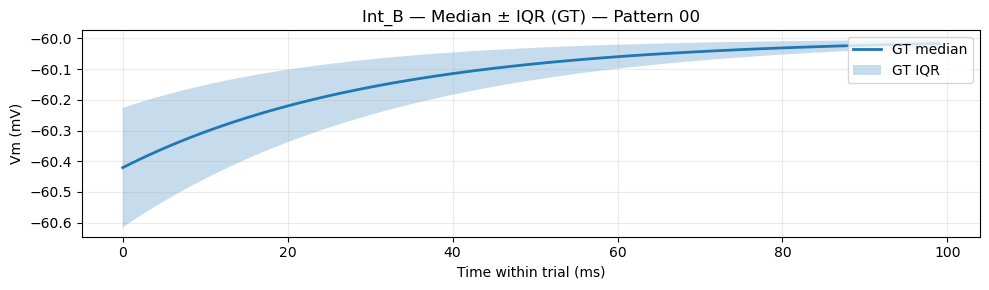

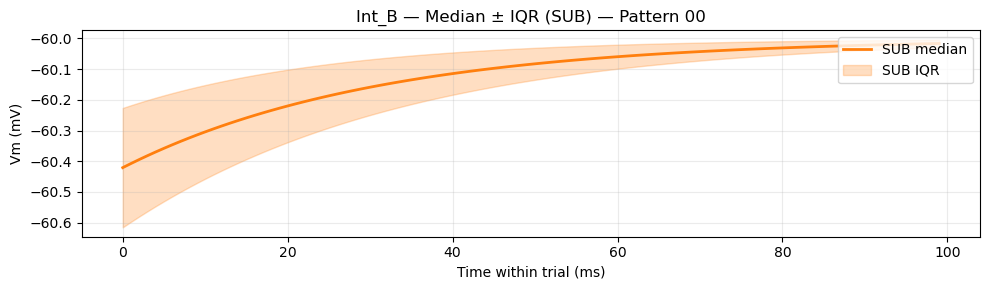

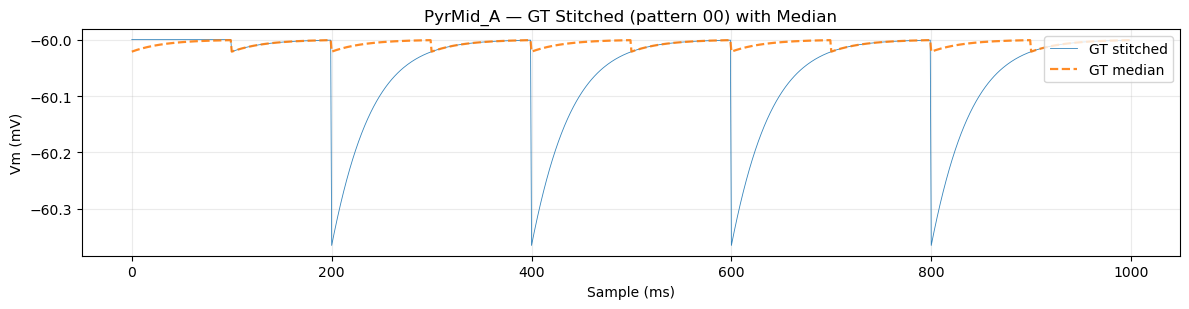

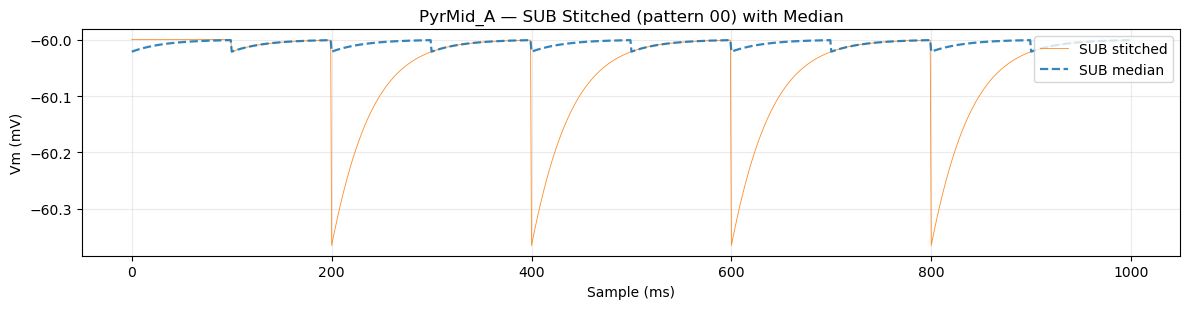

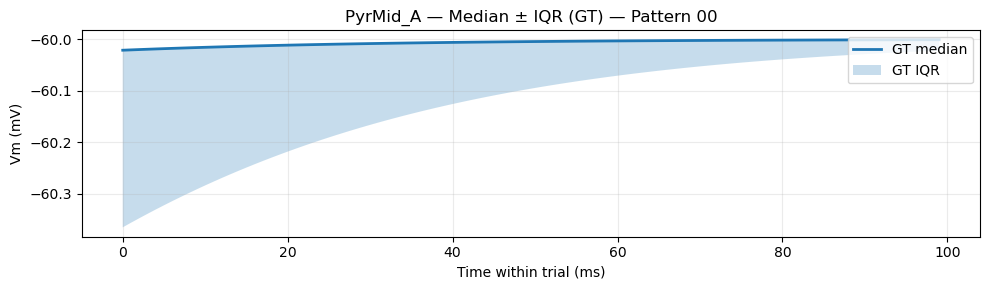

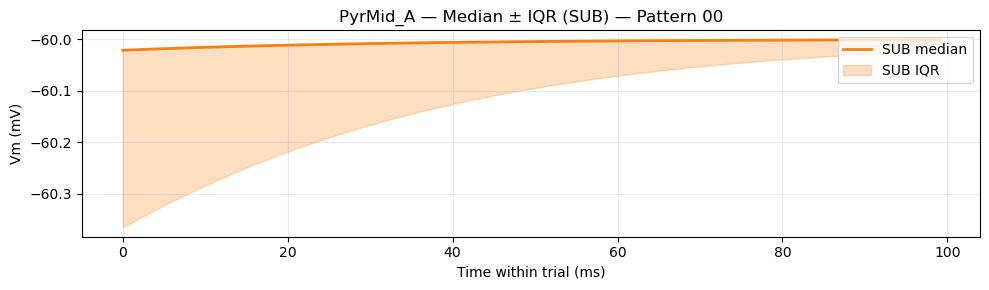

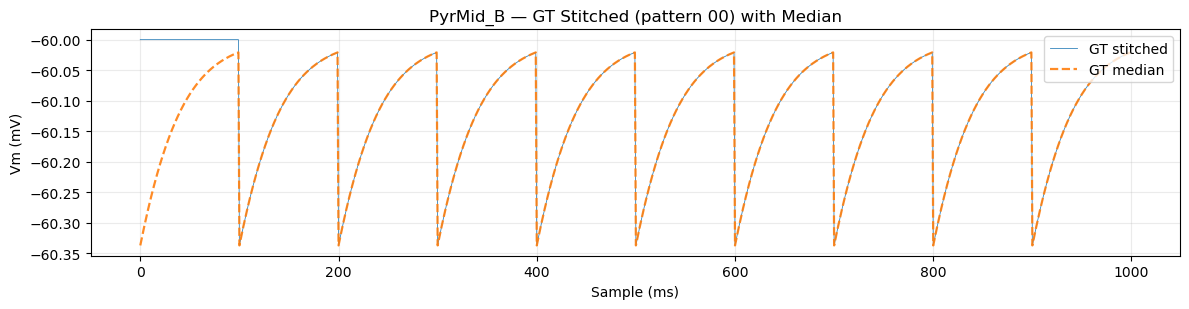

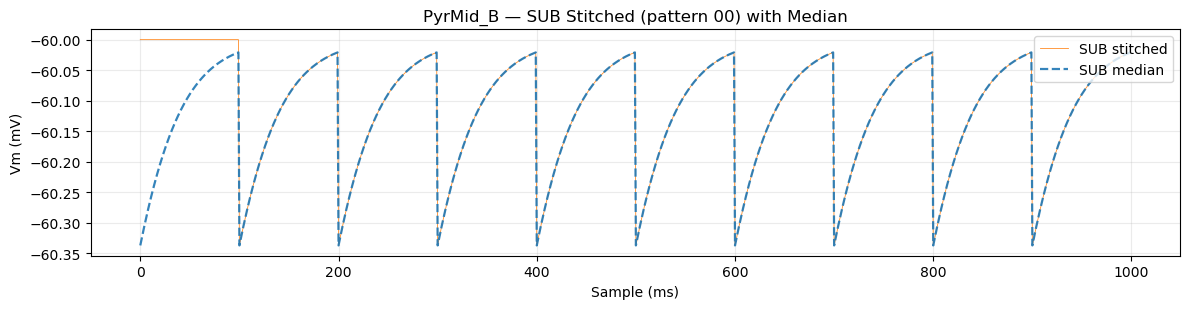

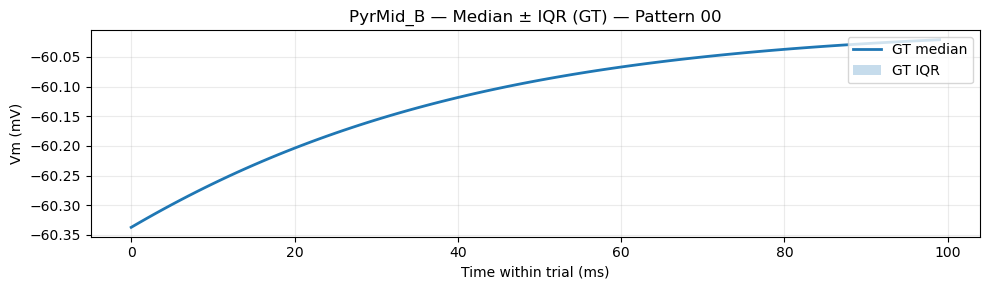

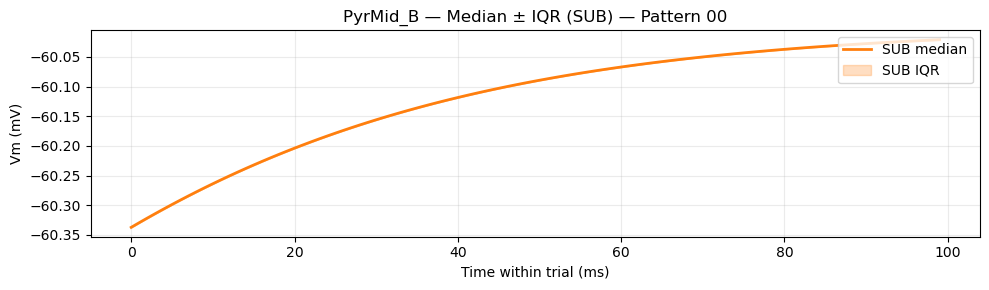

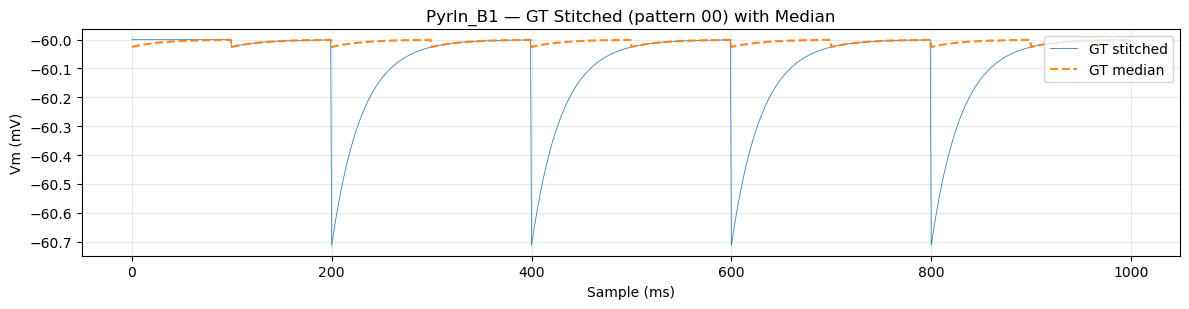

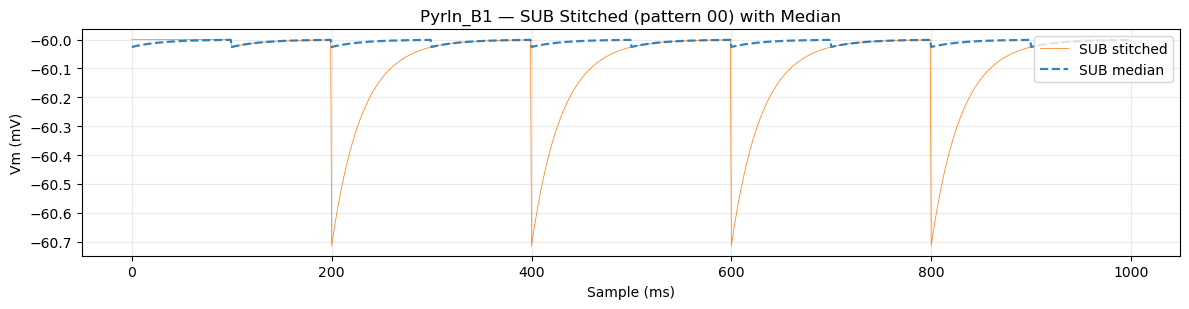

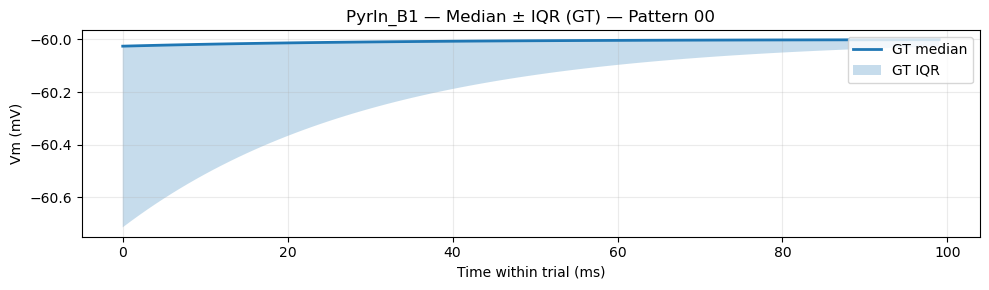

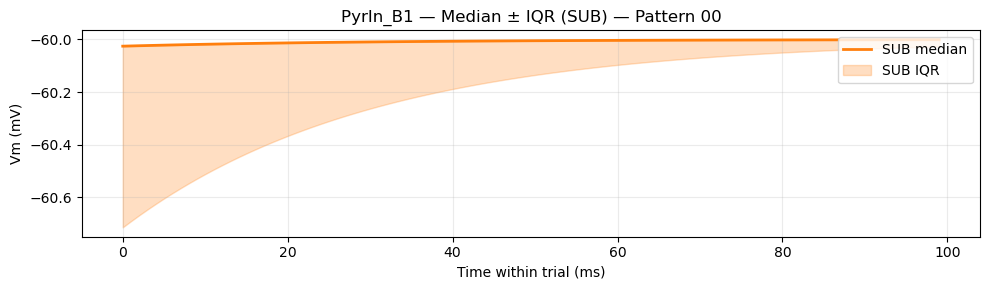

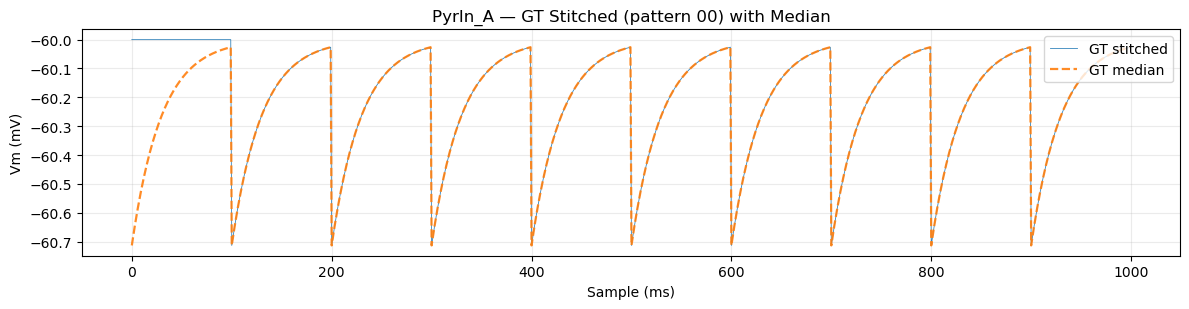

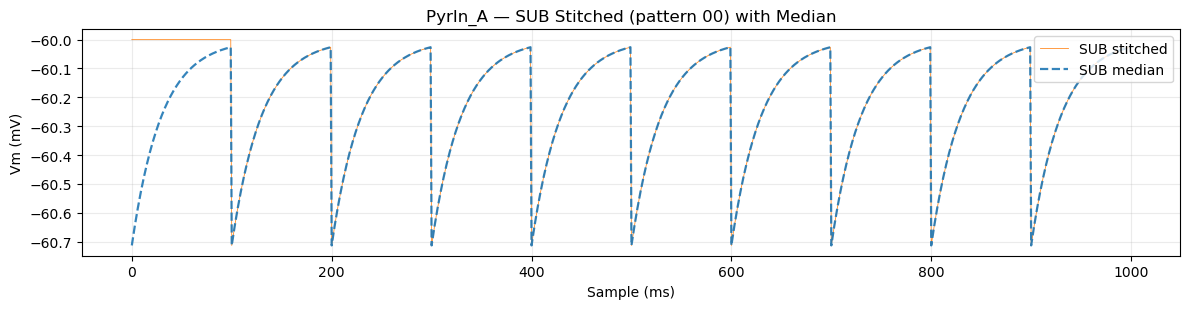

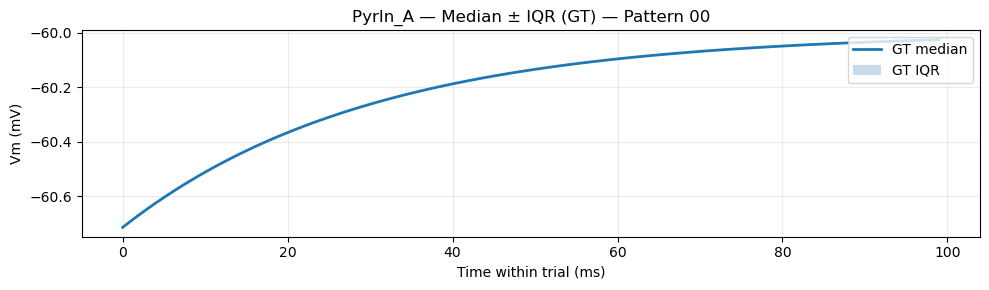

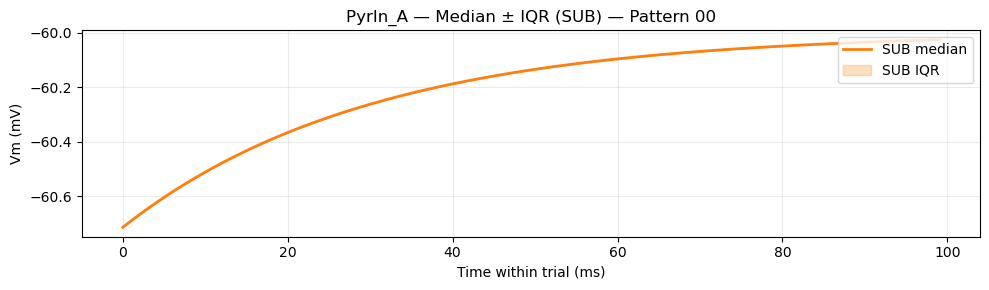

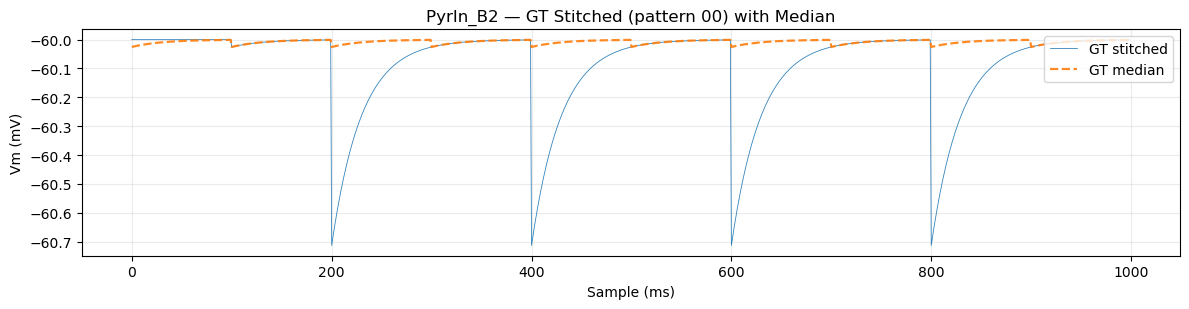

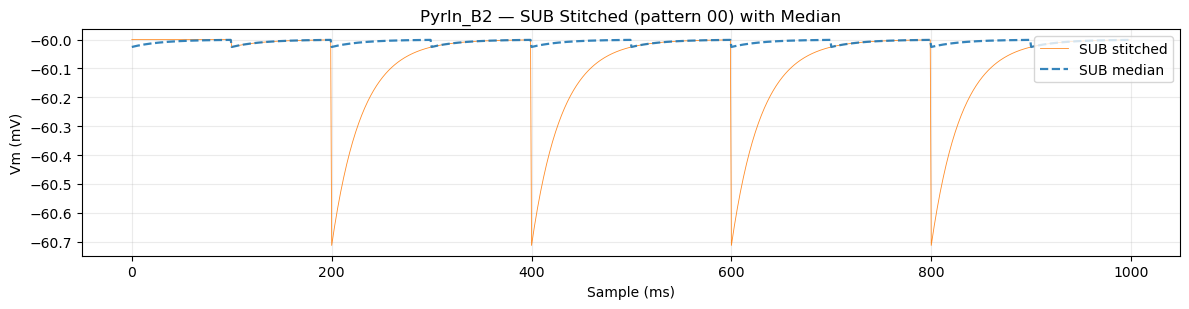

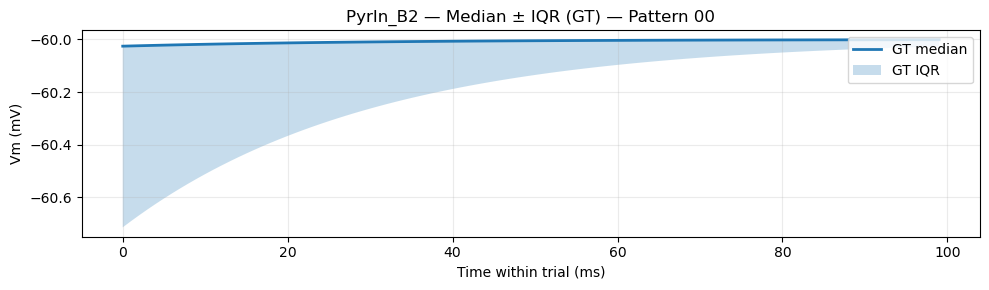

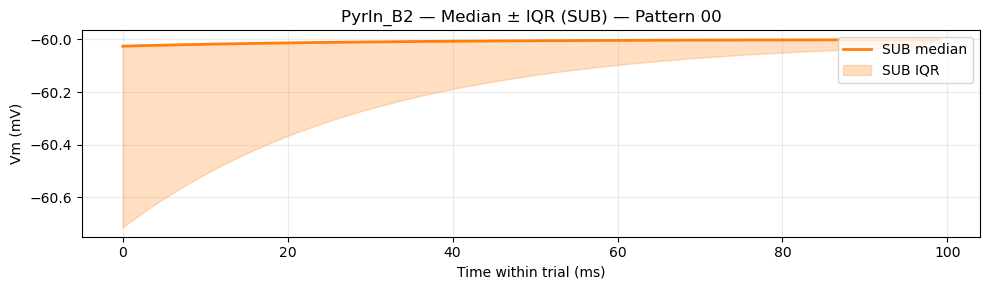

[1, 7, 9, 15, 17, 23, 25, 31, 33, 39]


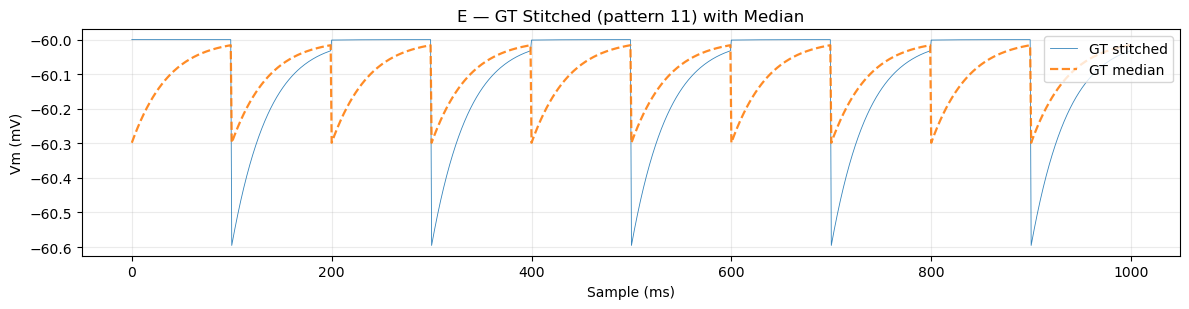

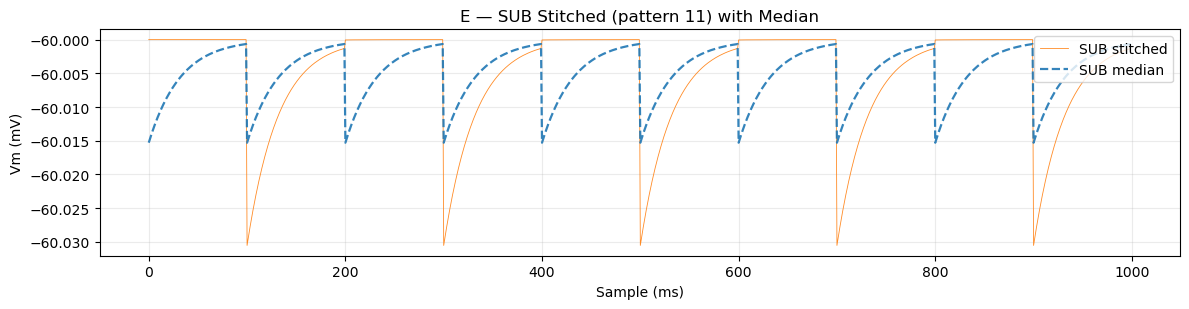

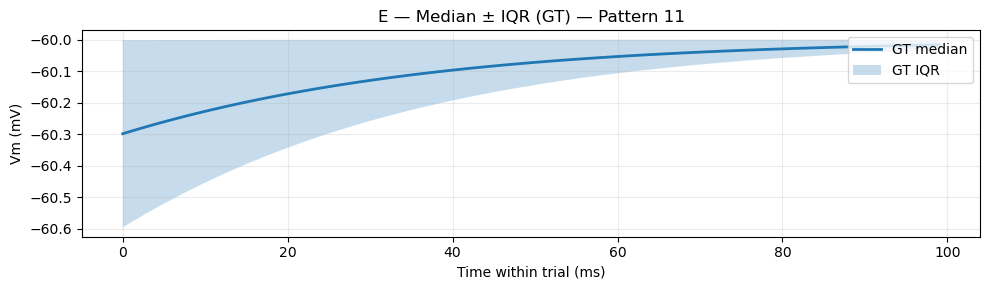

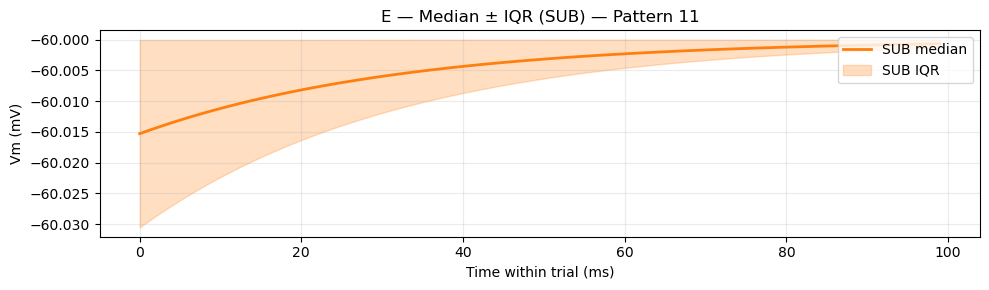

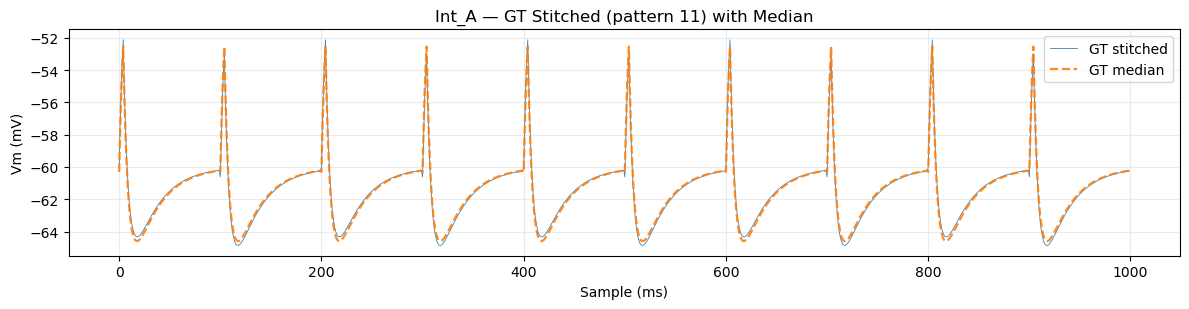

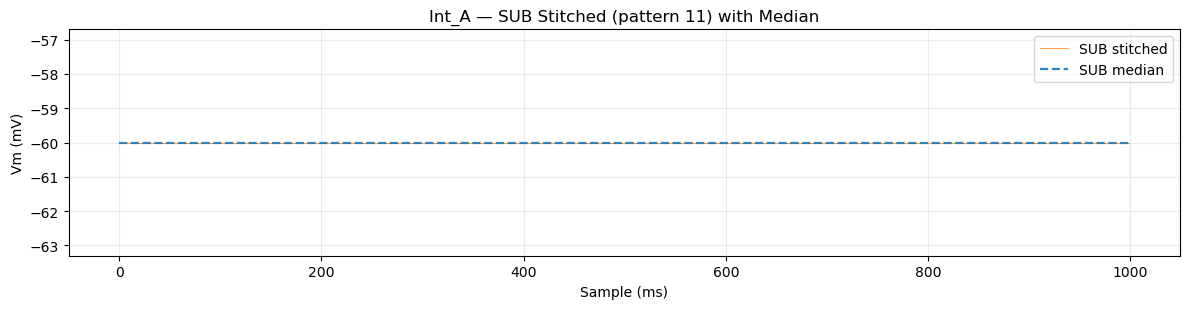

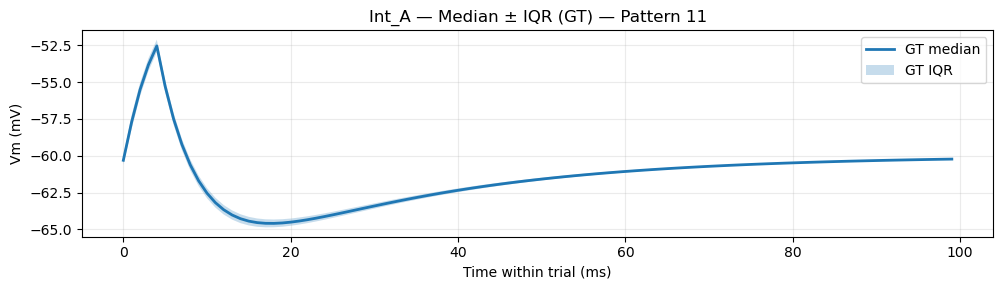

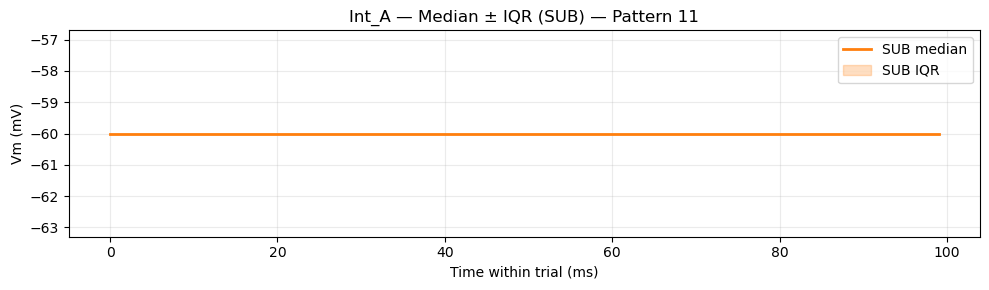

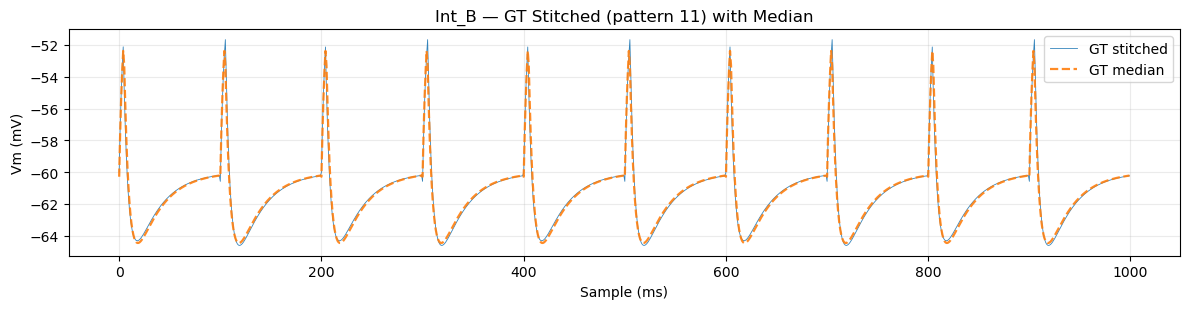

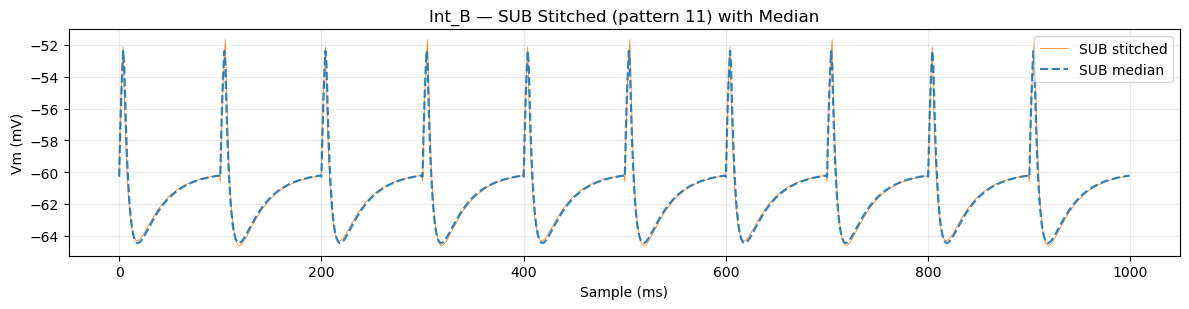

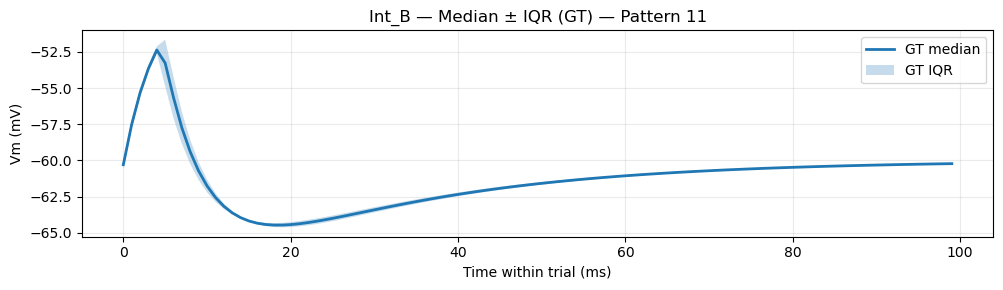

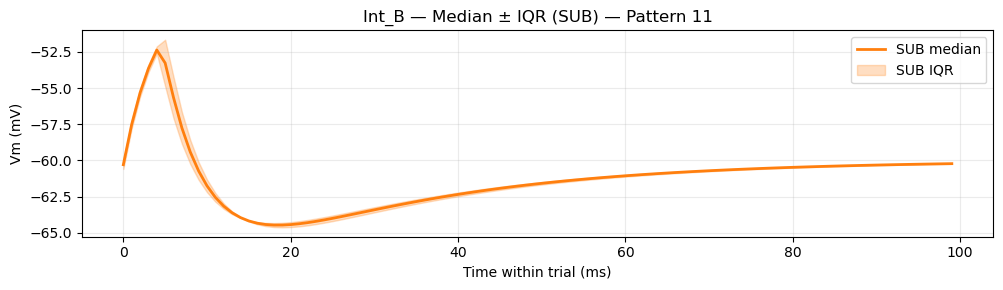

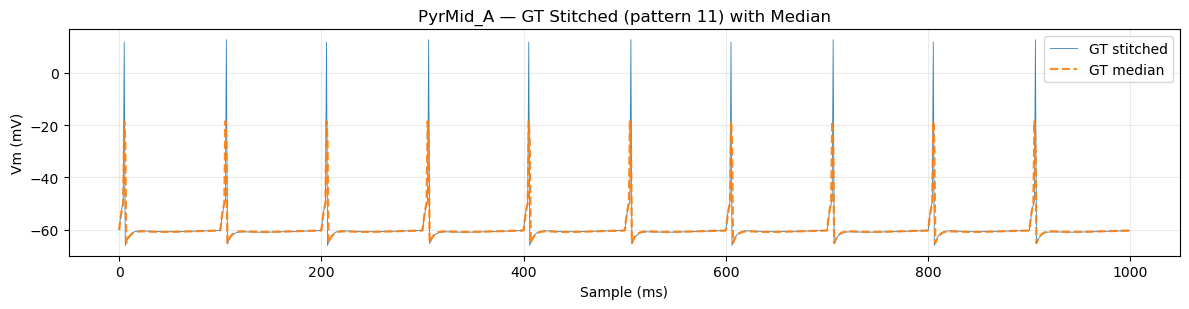

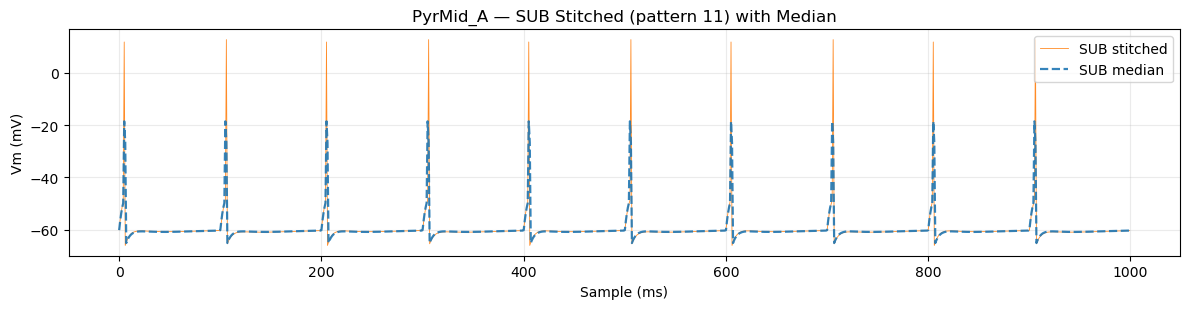

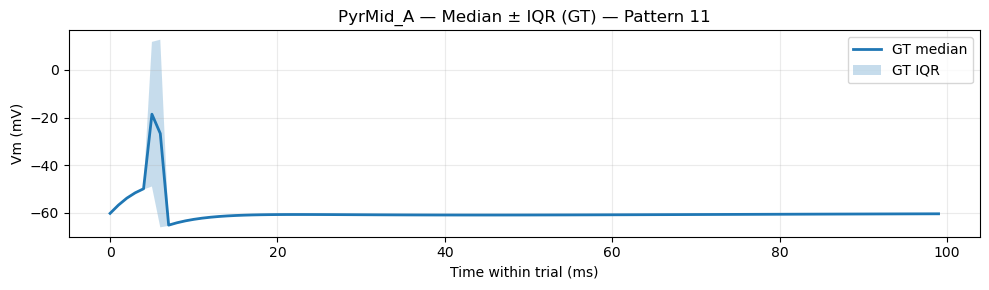

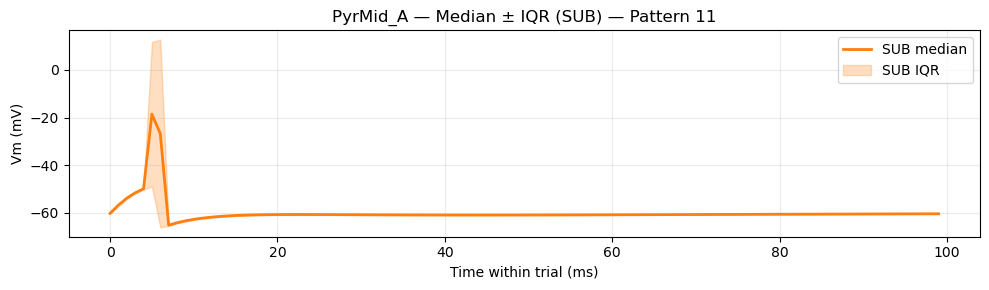

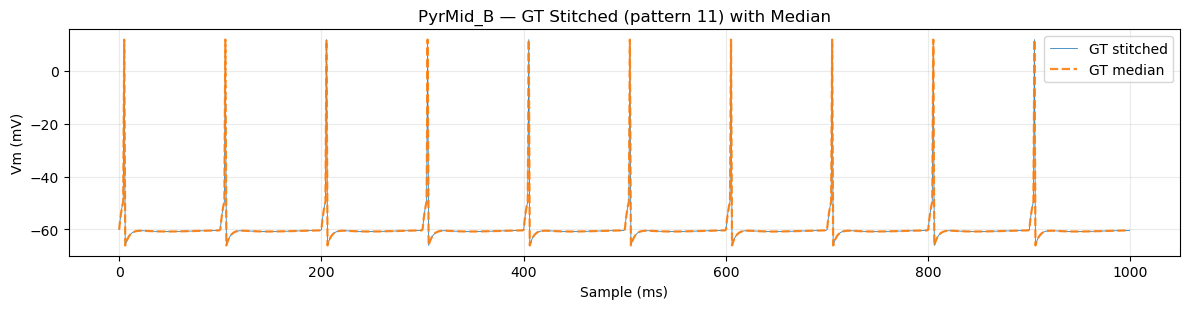

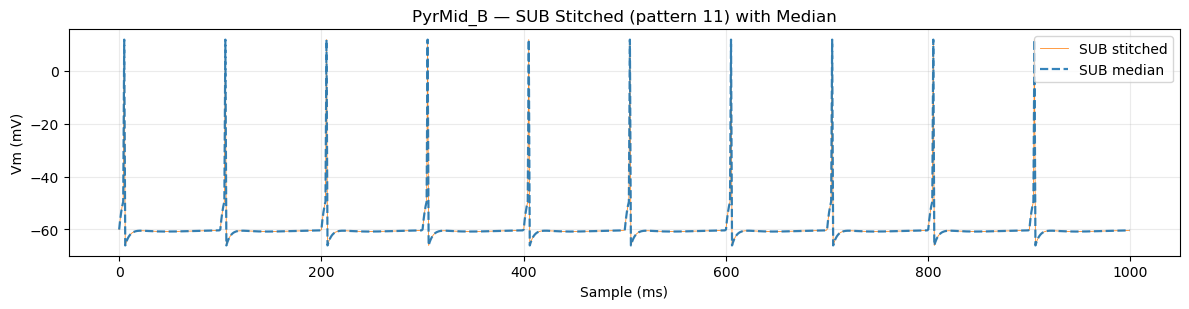

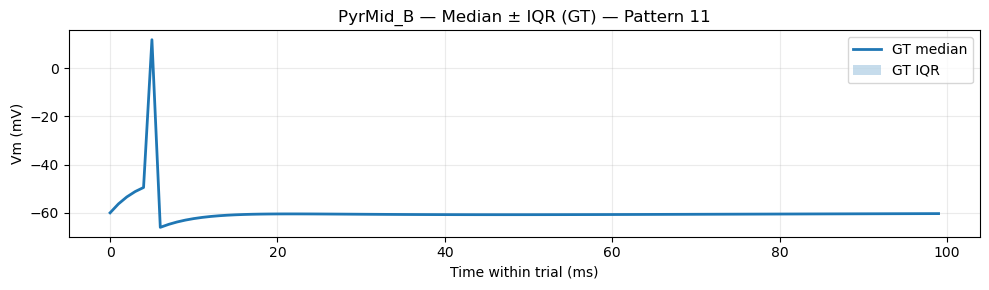

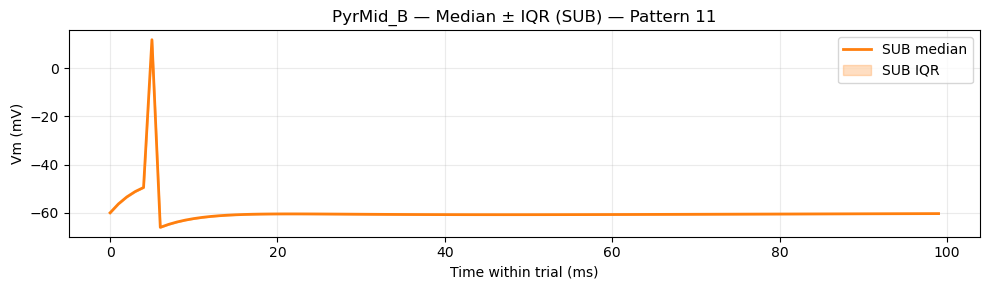

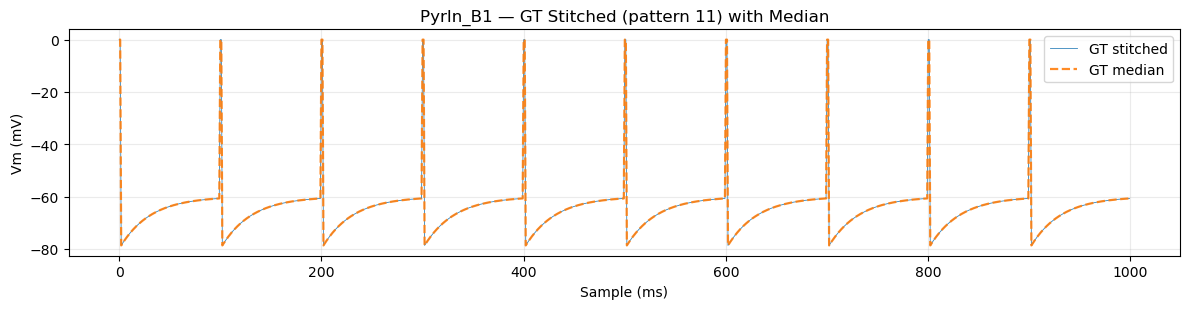

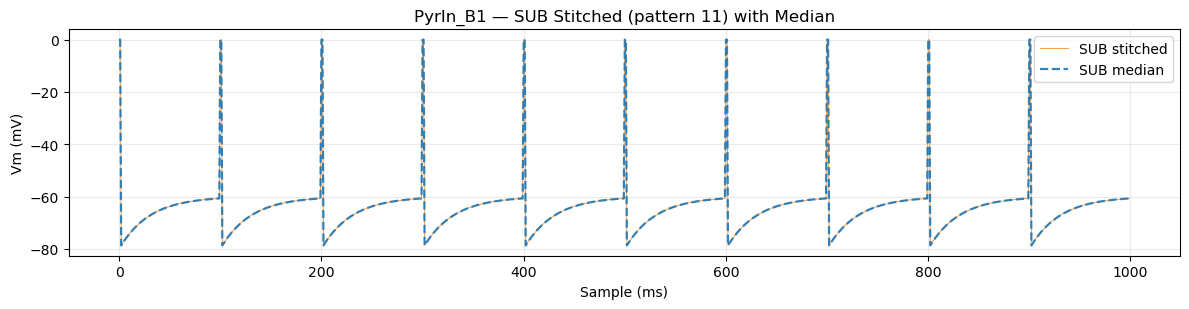

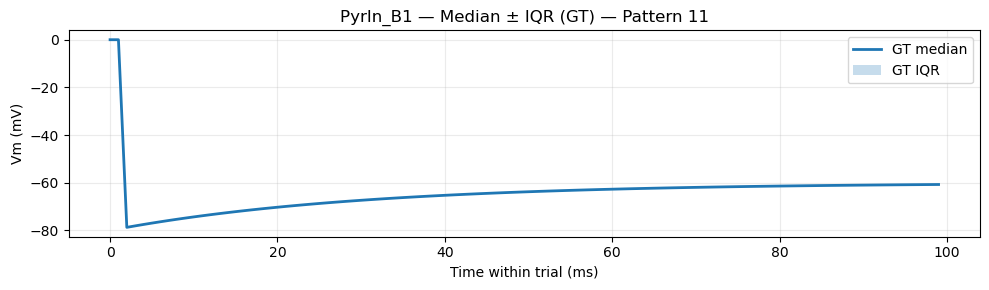

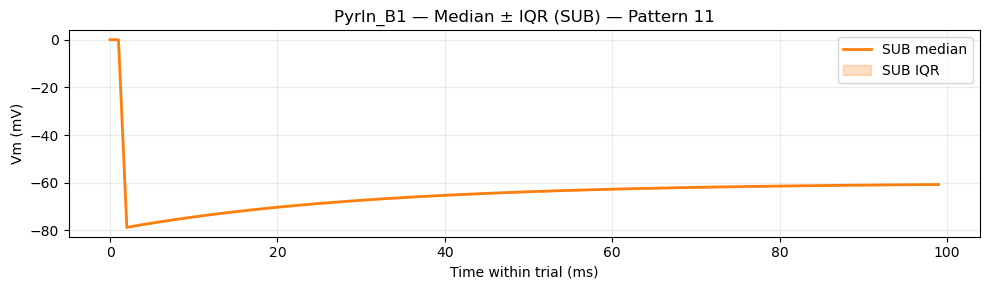

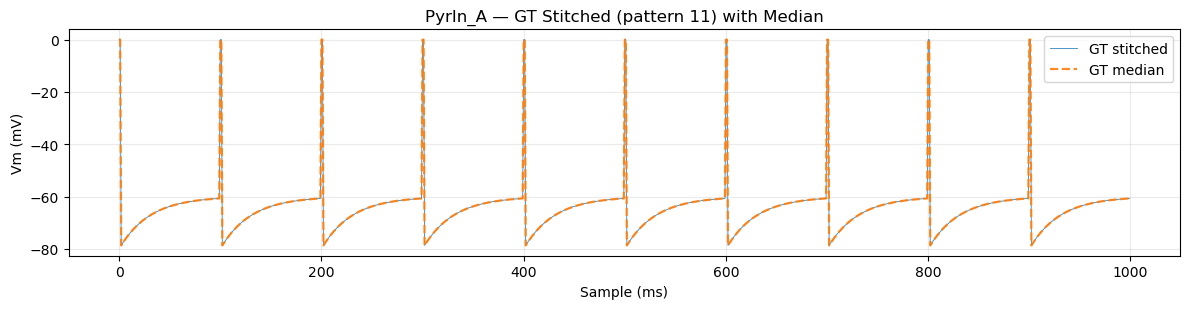

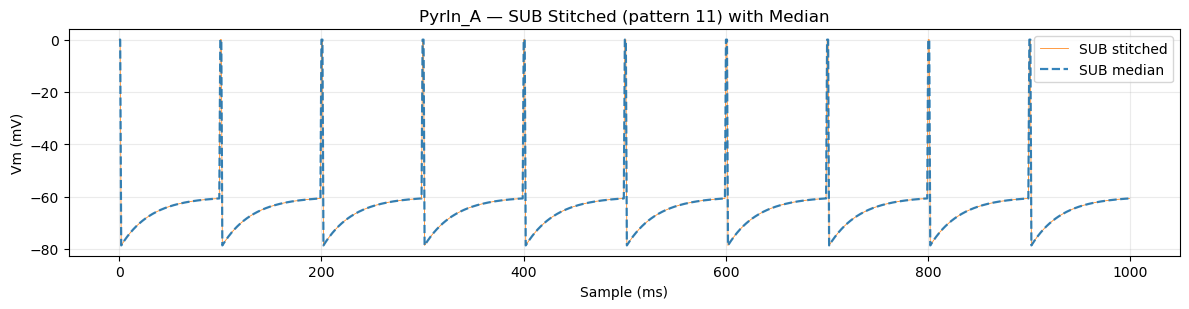

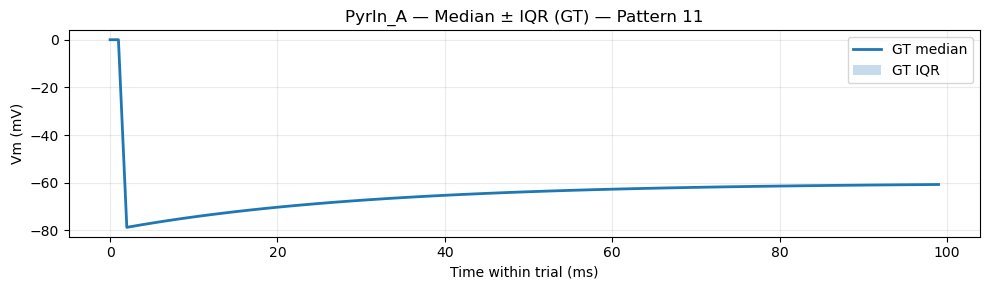

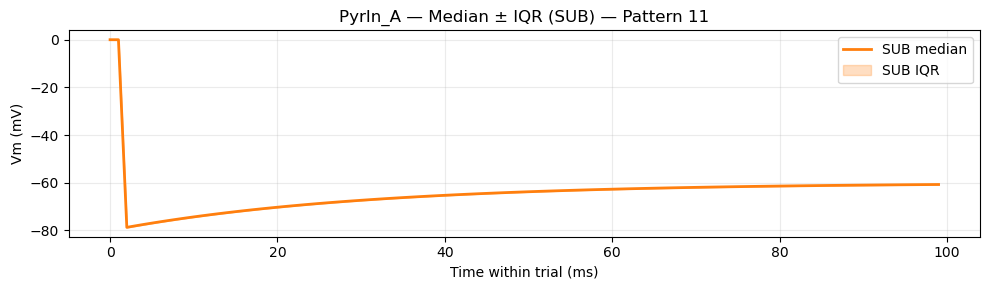

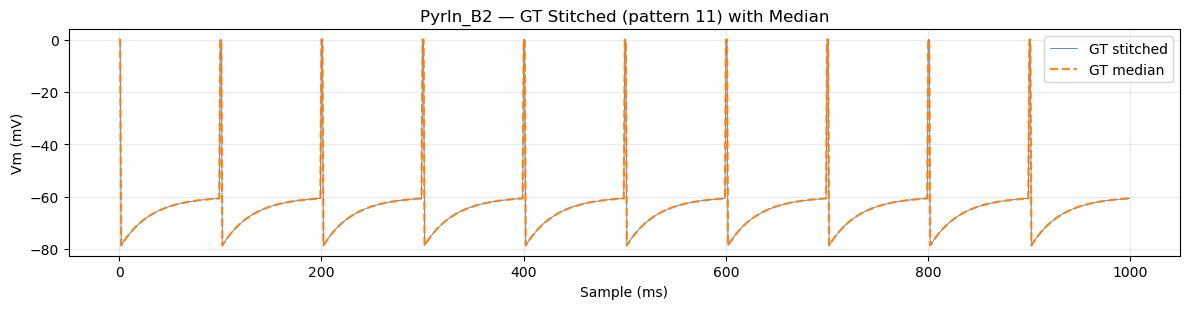

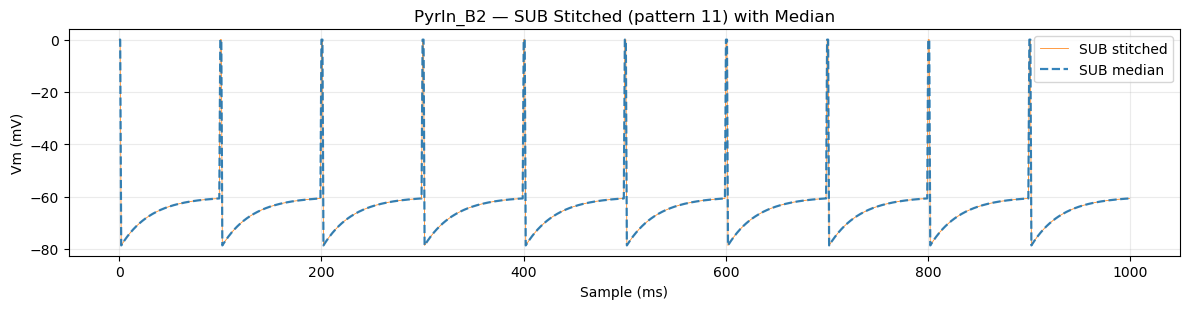

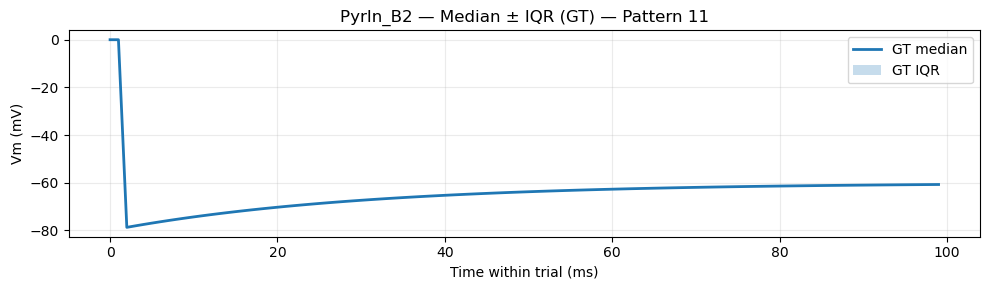

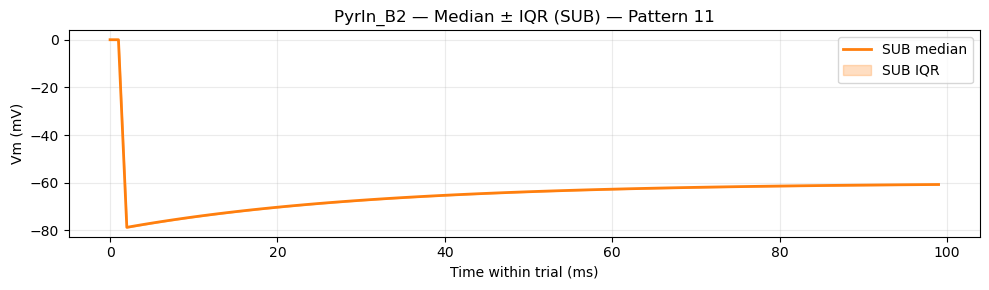

[2, 6, 10, 14, 18, 22, 26, 30, 34, 38]


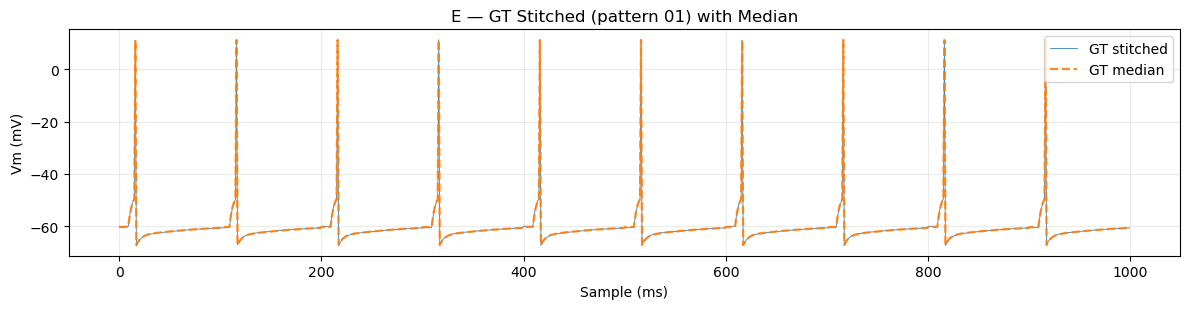

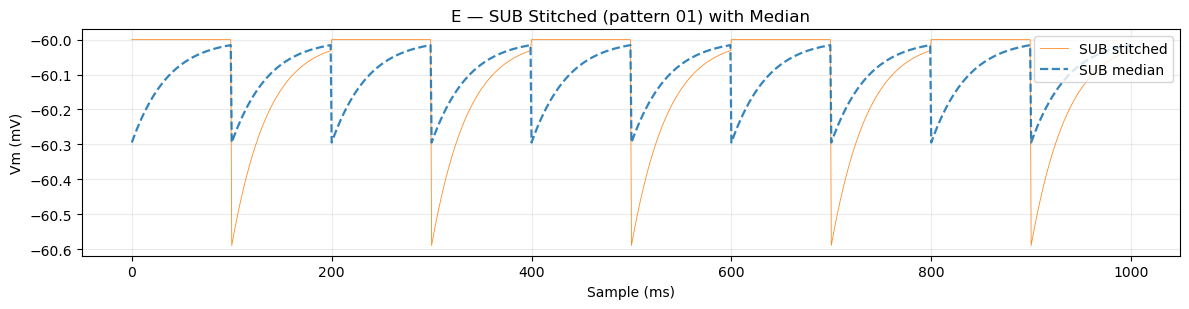

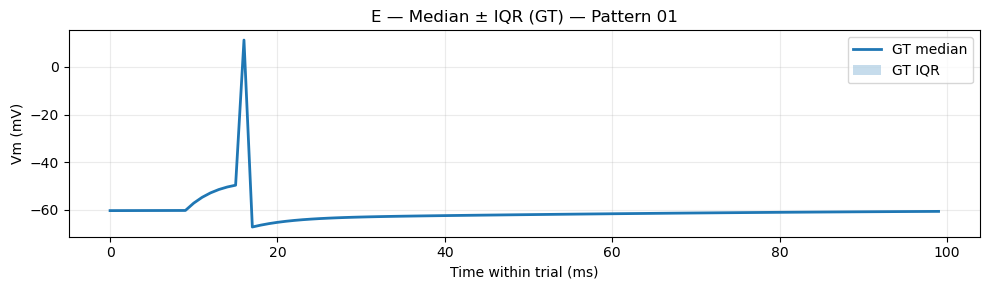

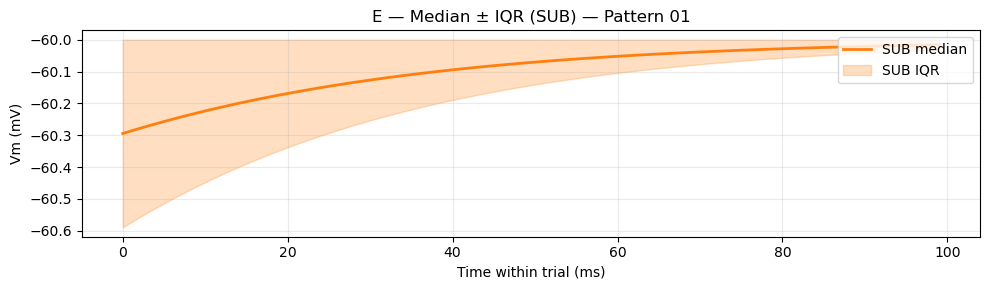

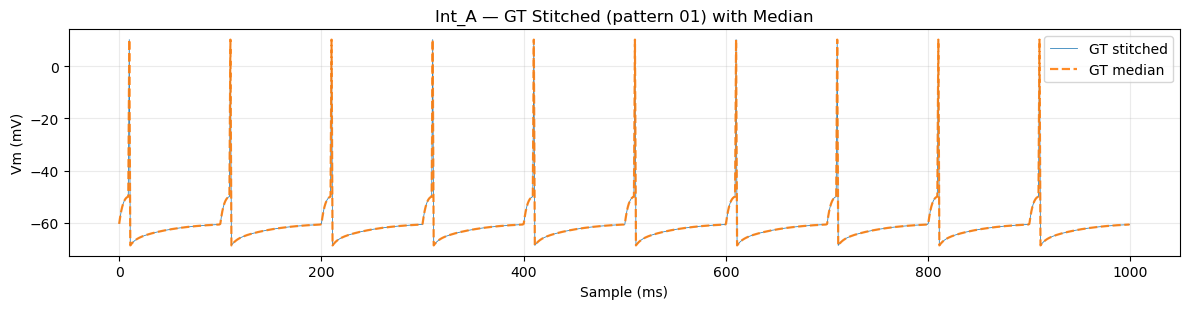

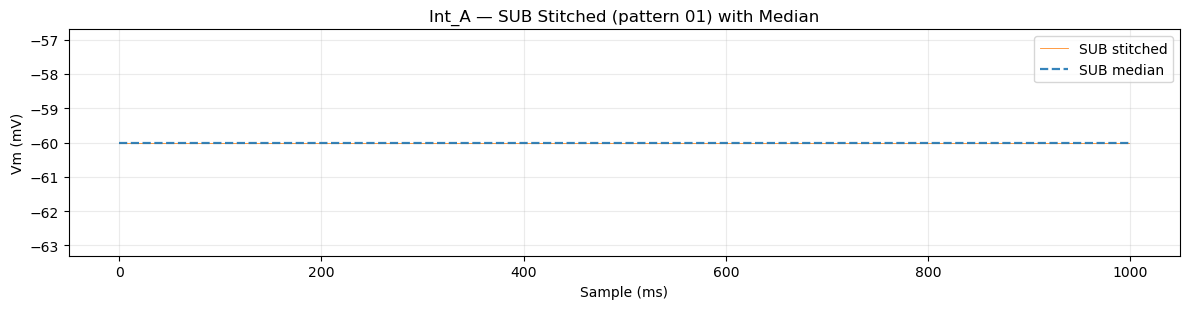

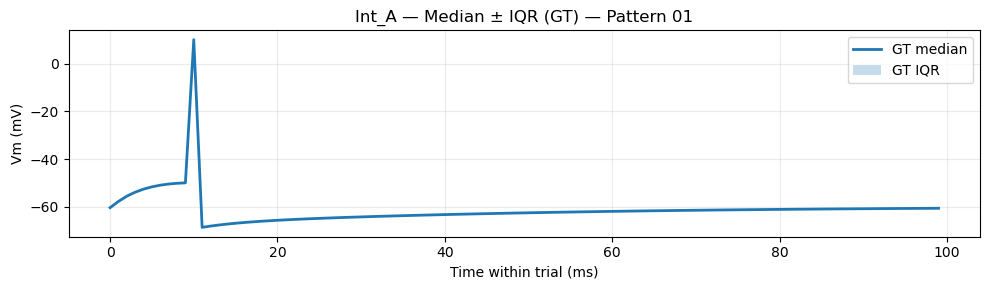

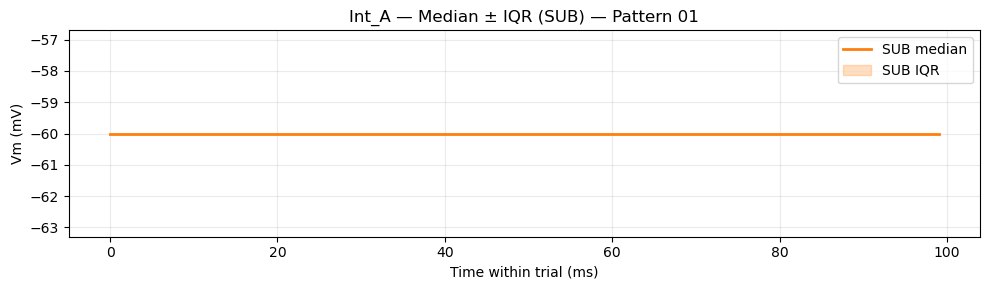

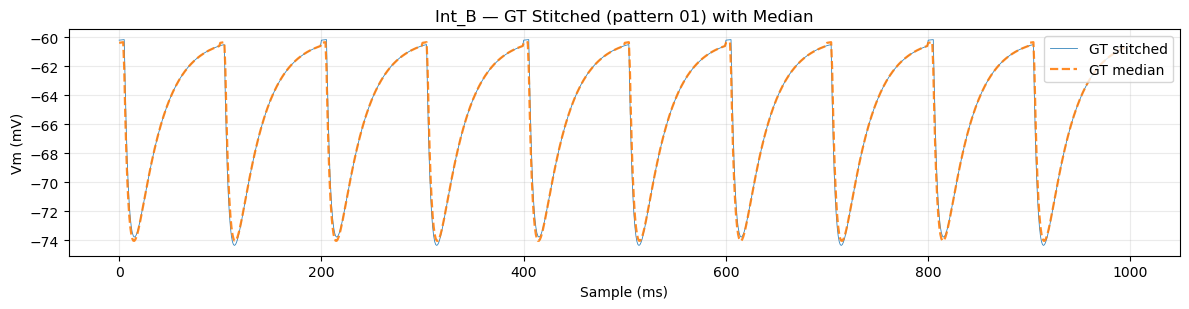

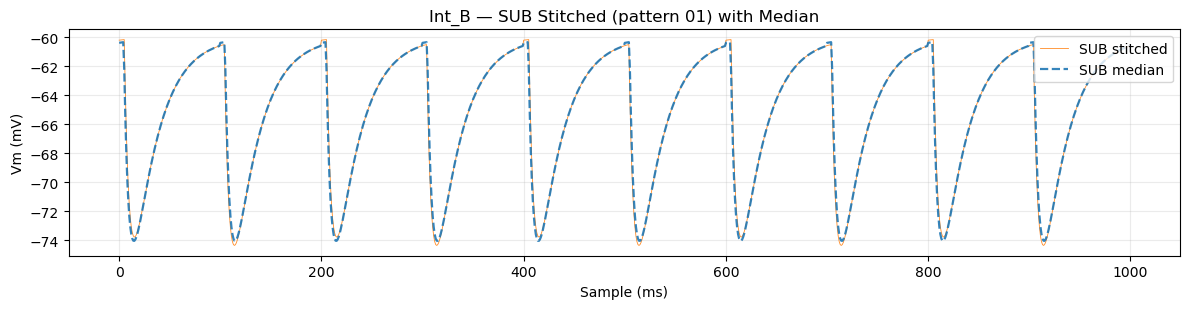

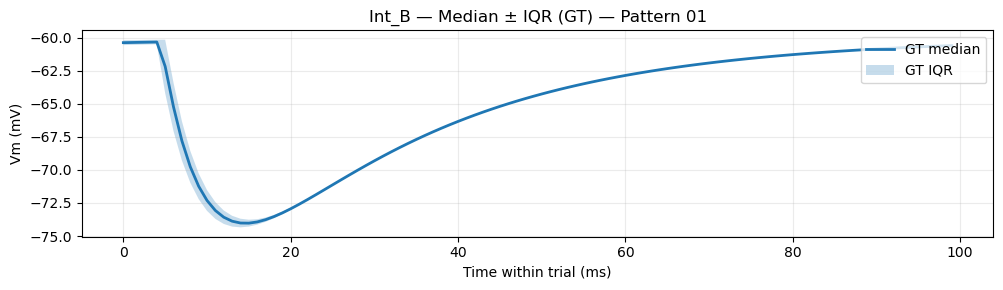

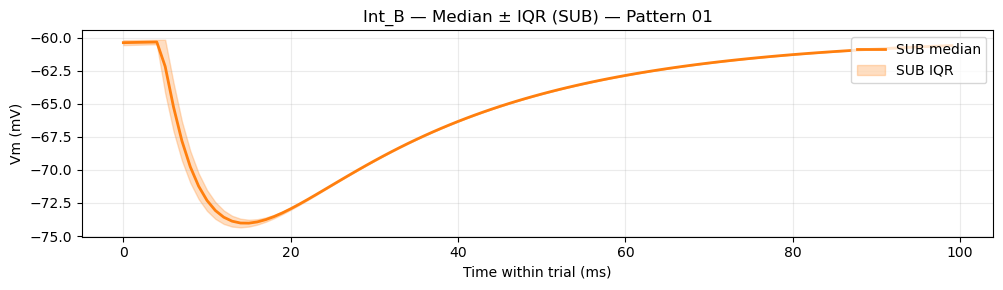

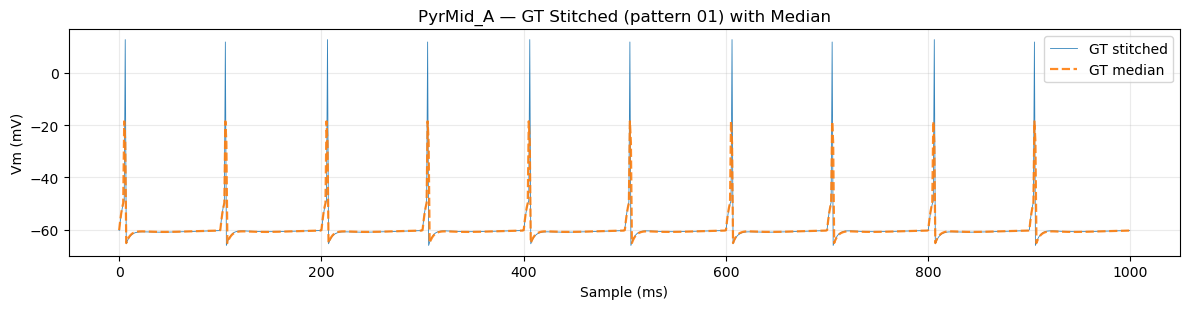

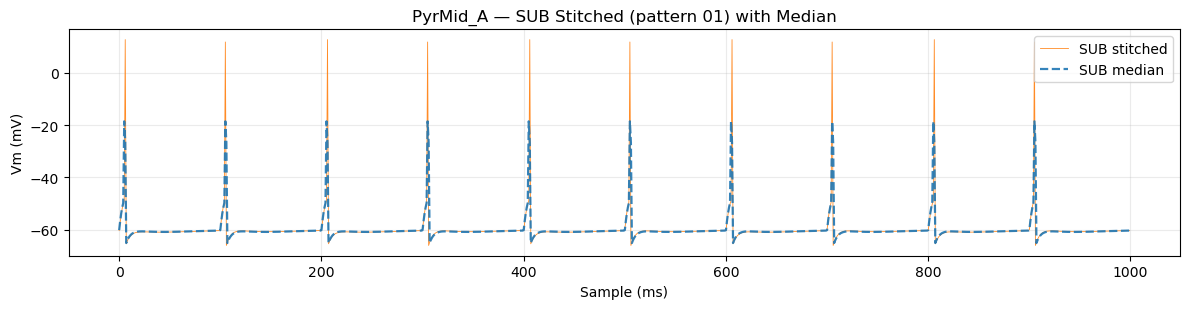

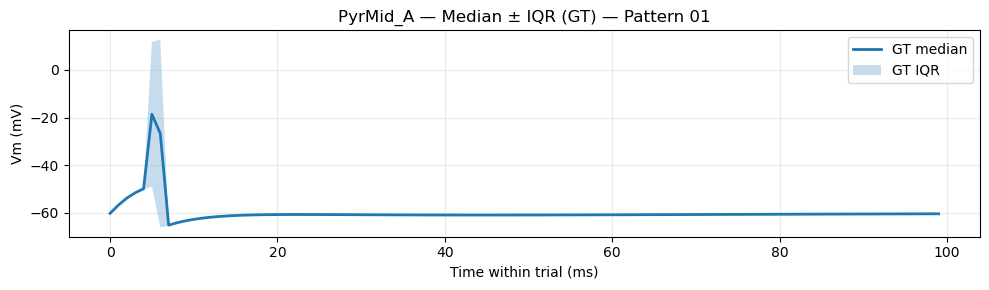

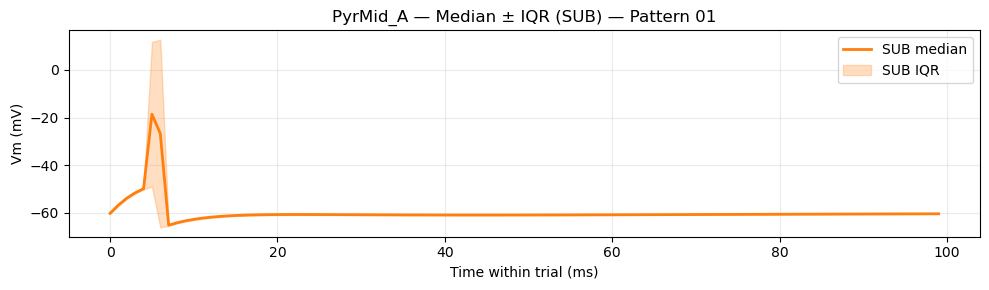

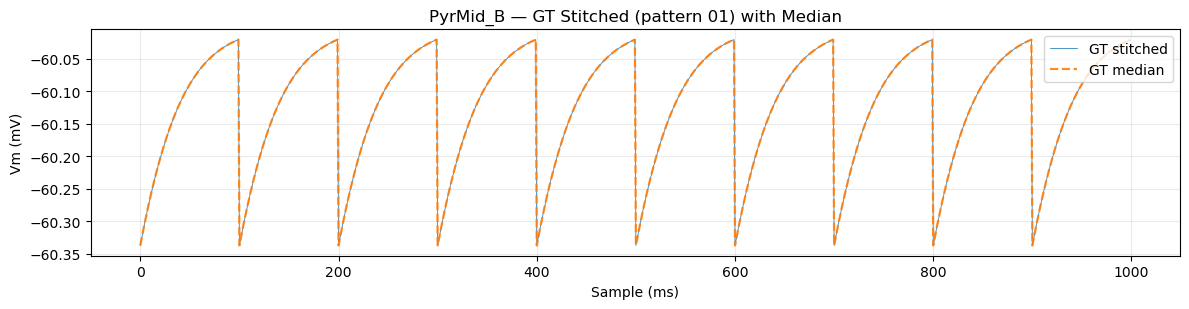

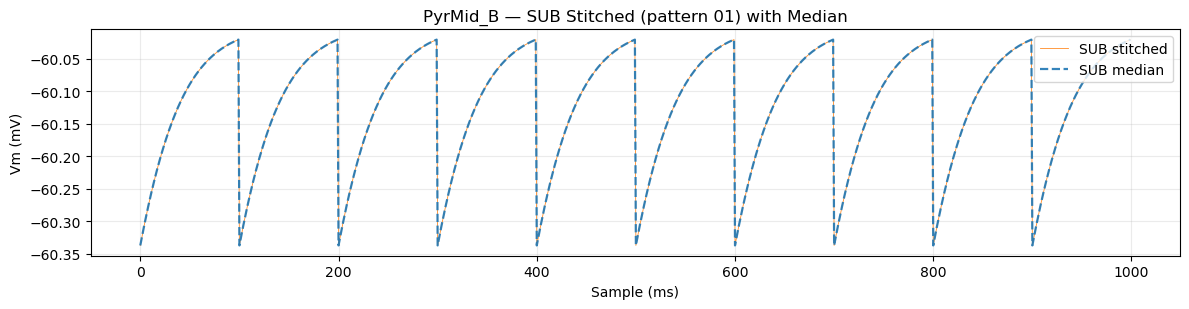

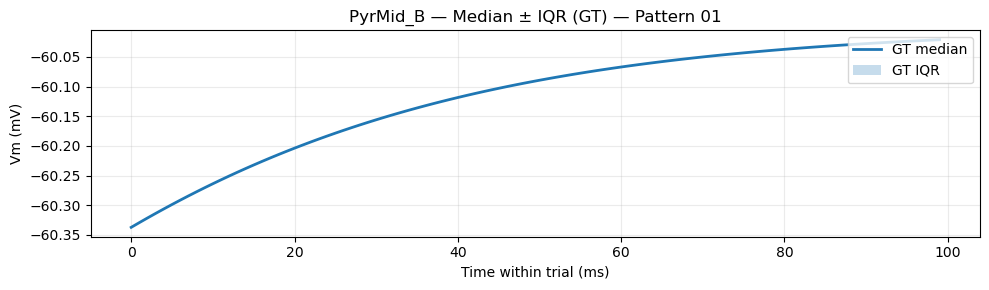

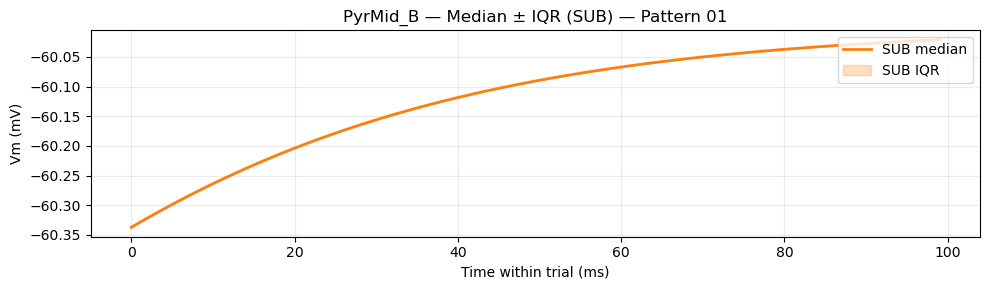

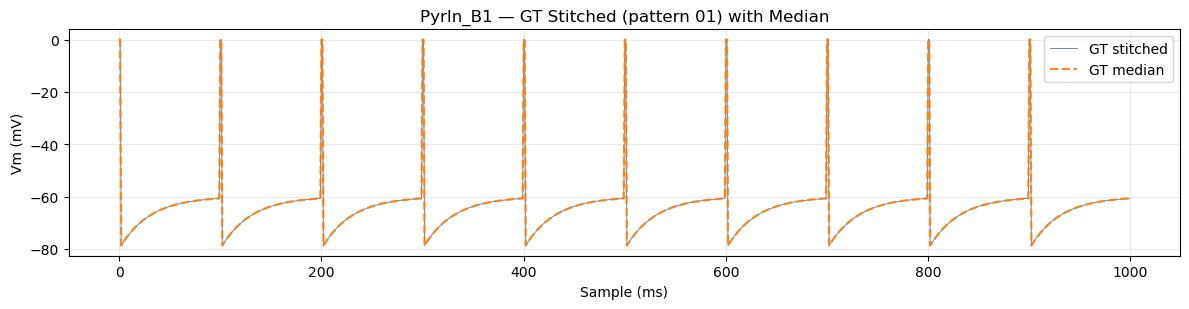

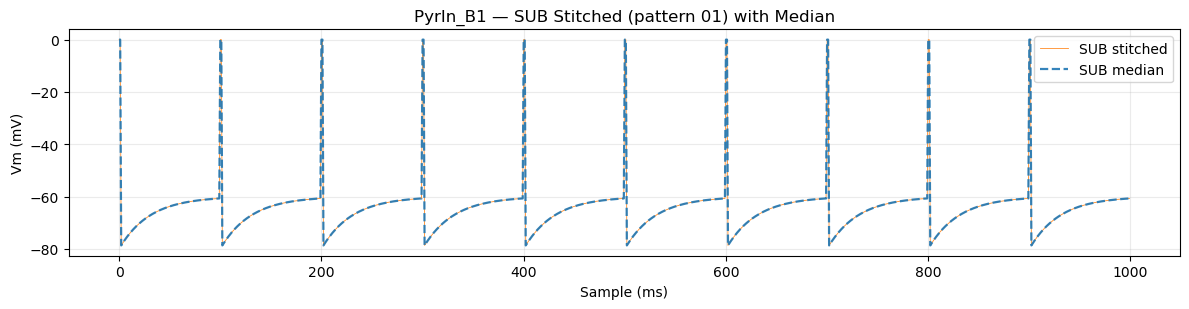

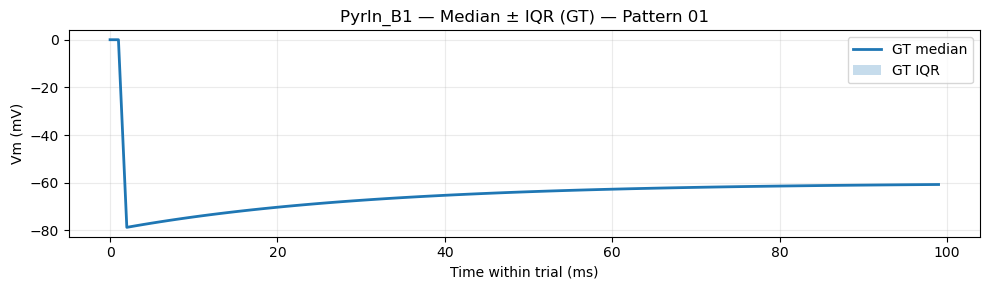

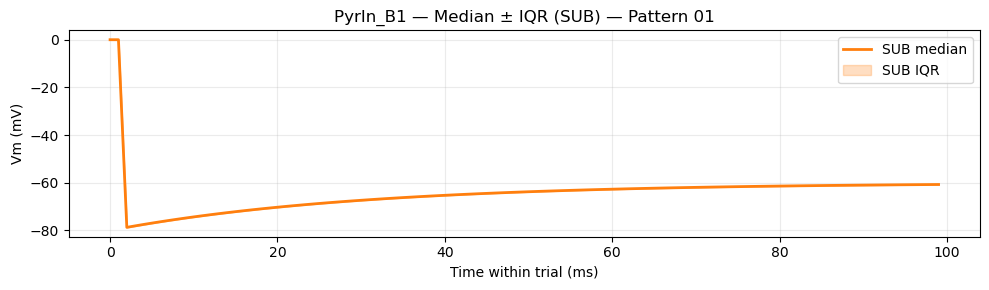

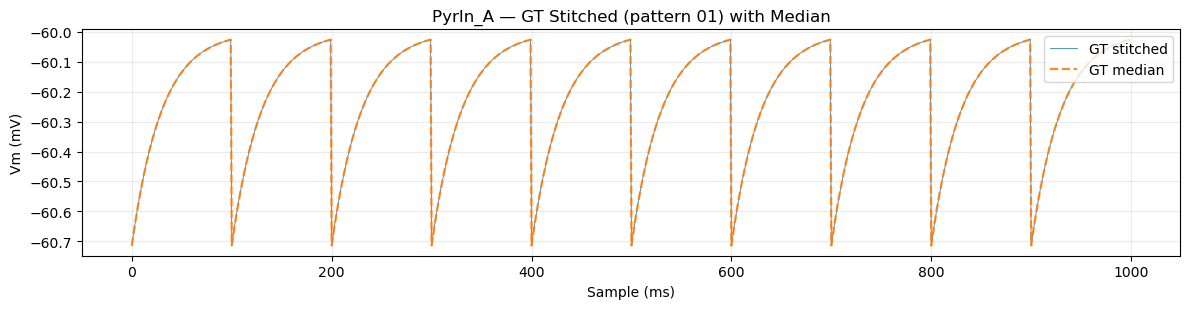

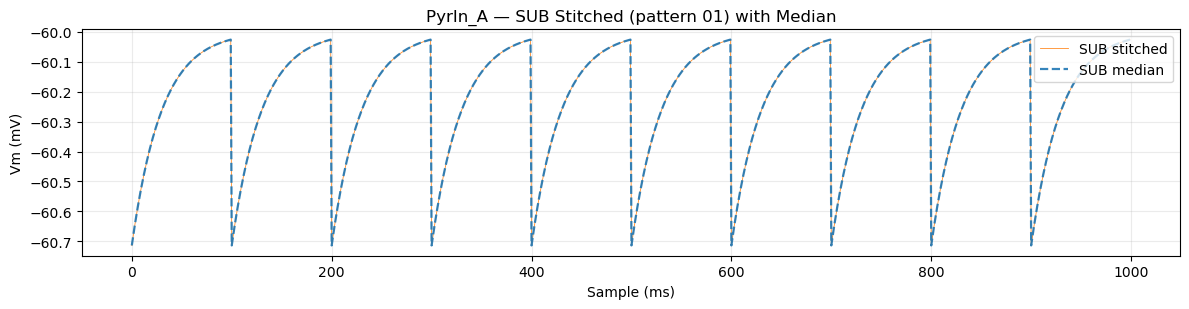

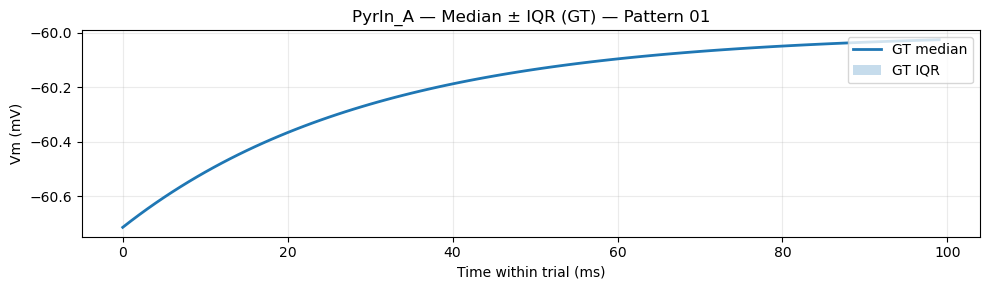

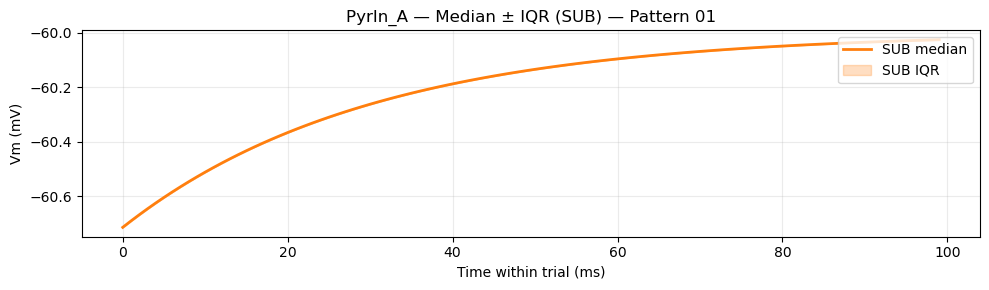

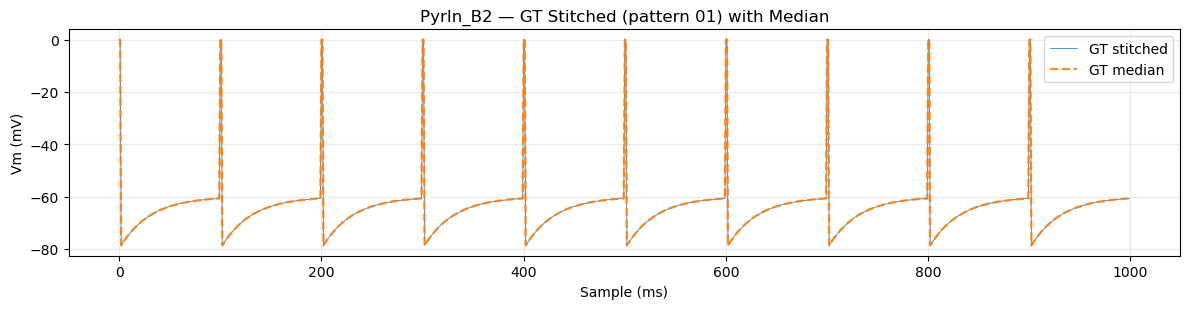

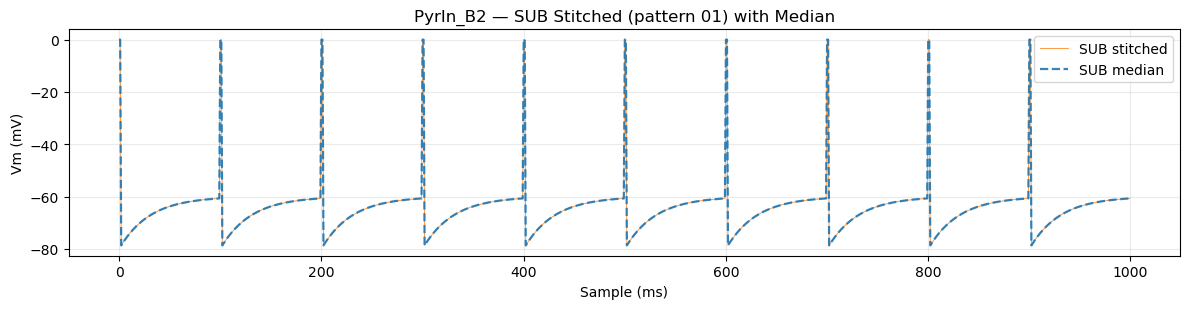

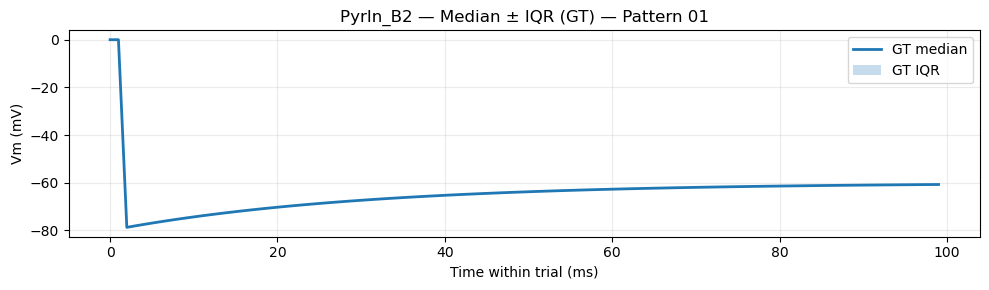

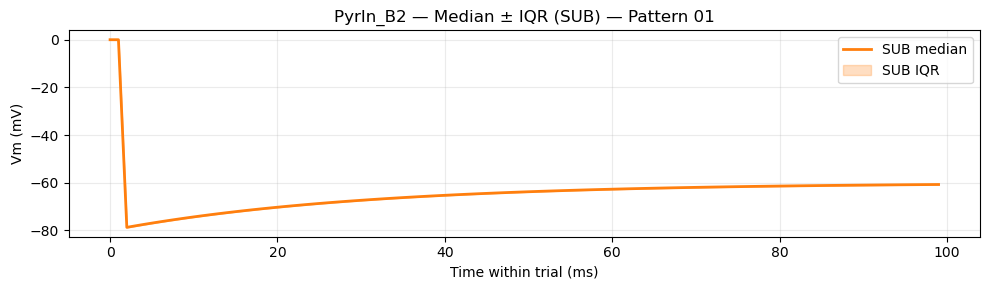

[3, 5, 11, 13, 19, 21, 27, 29, 35, 37]


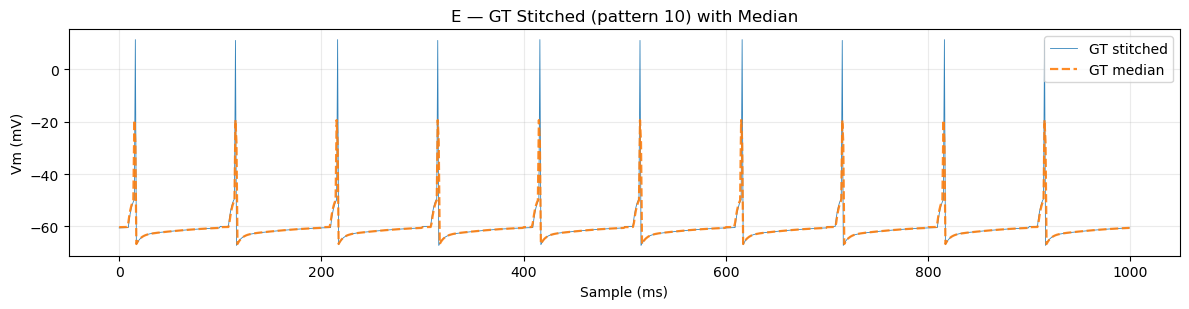

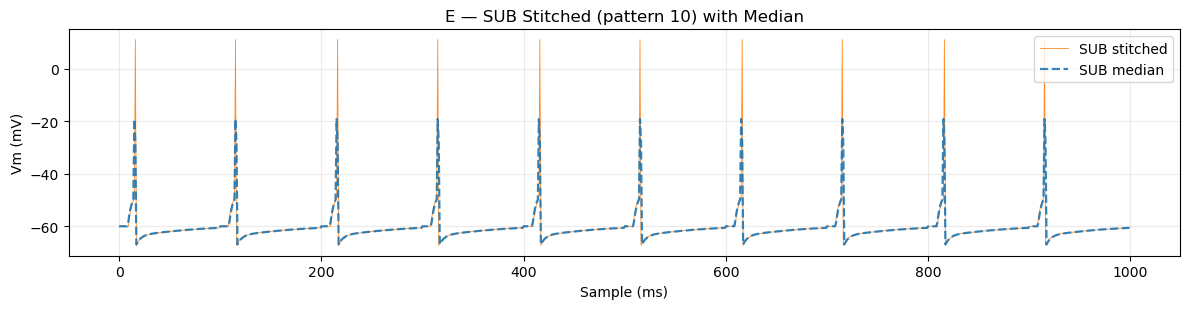

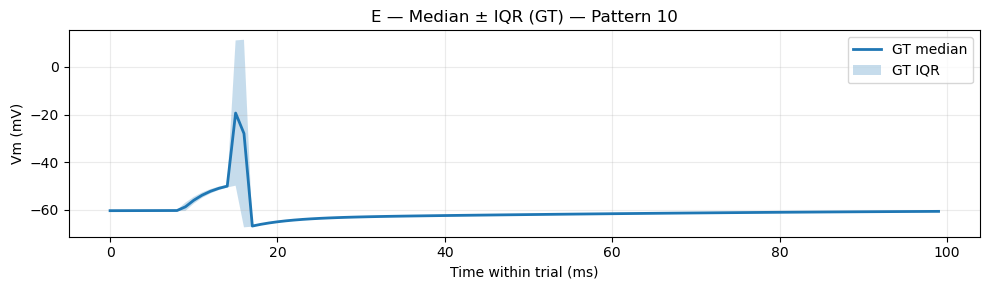

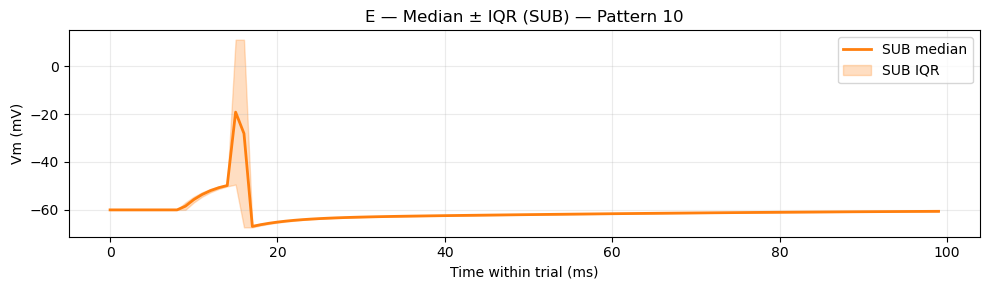

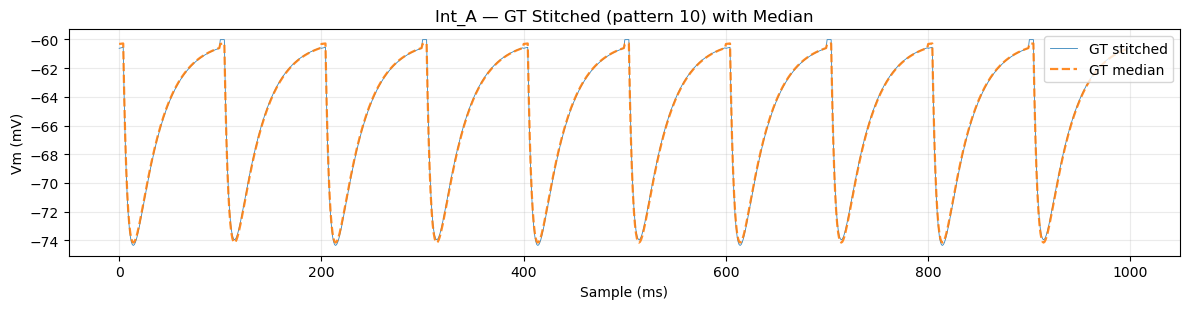

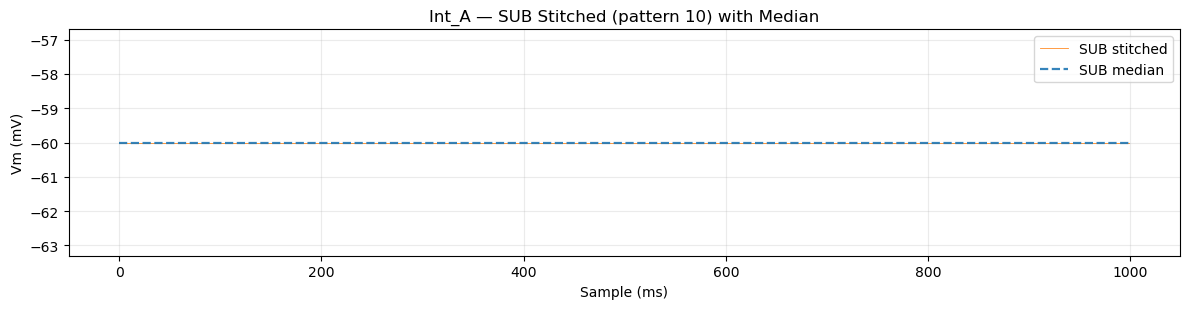

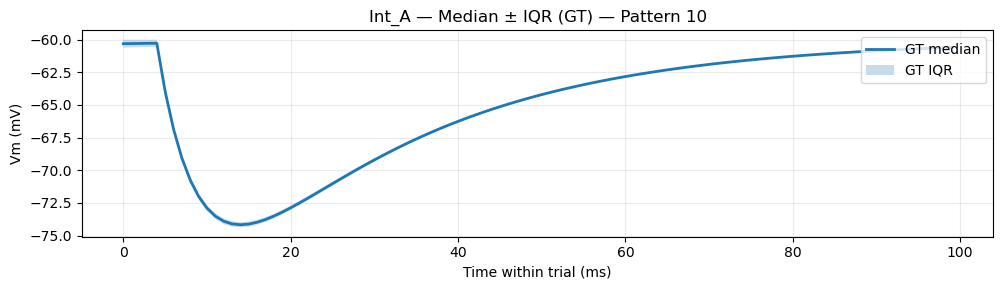

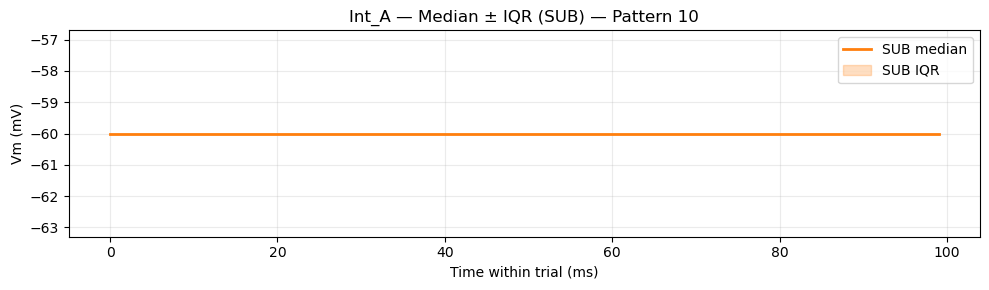

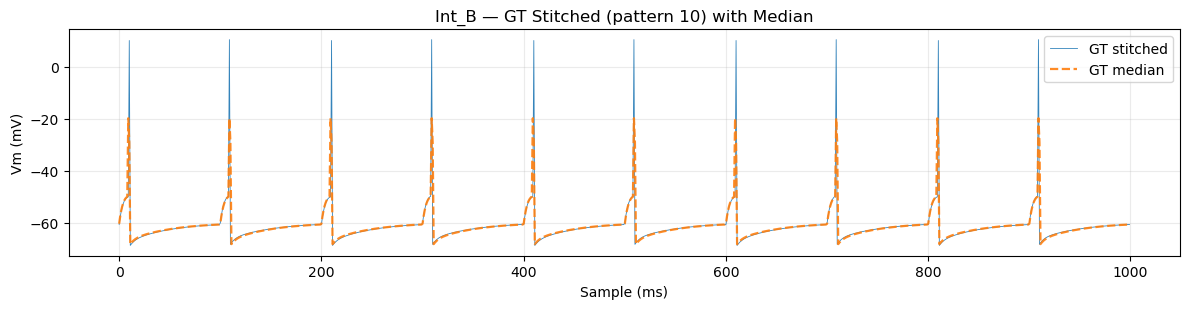

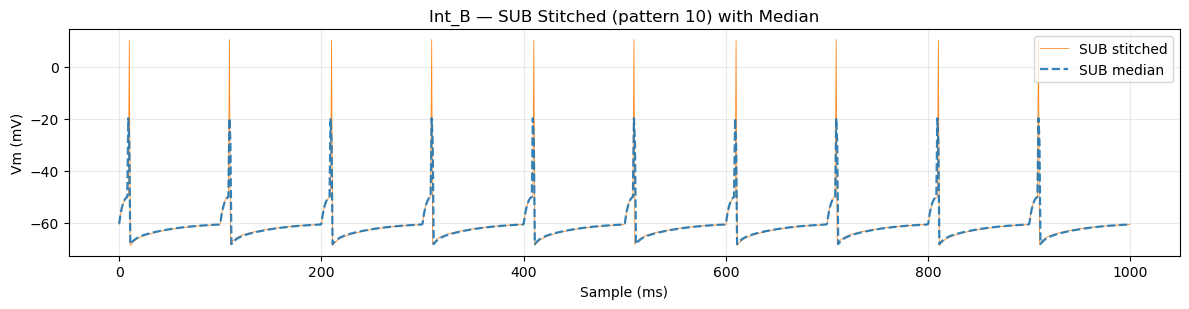

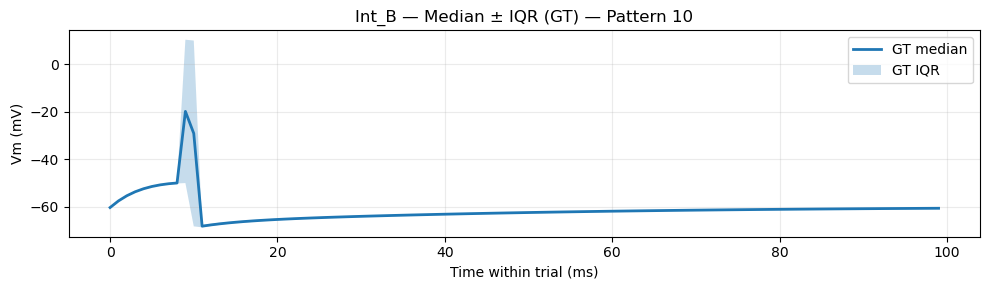

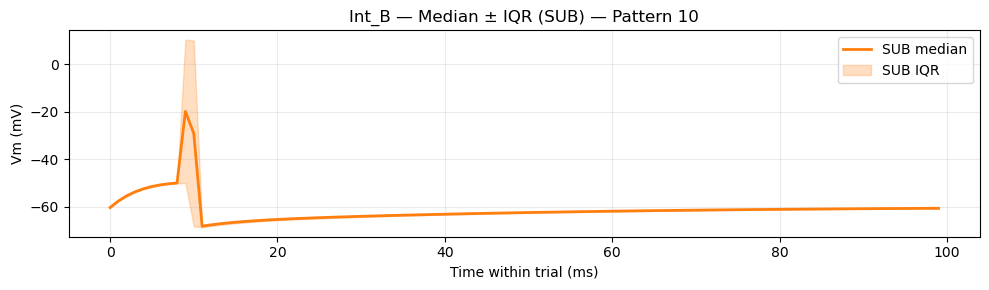

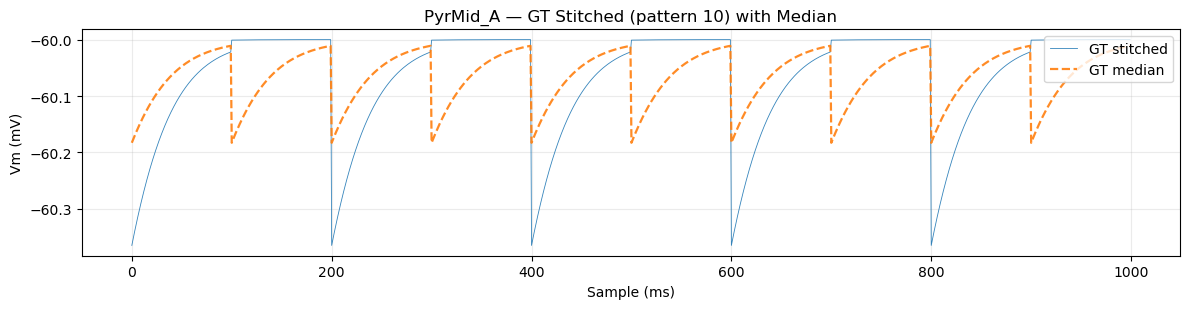

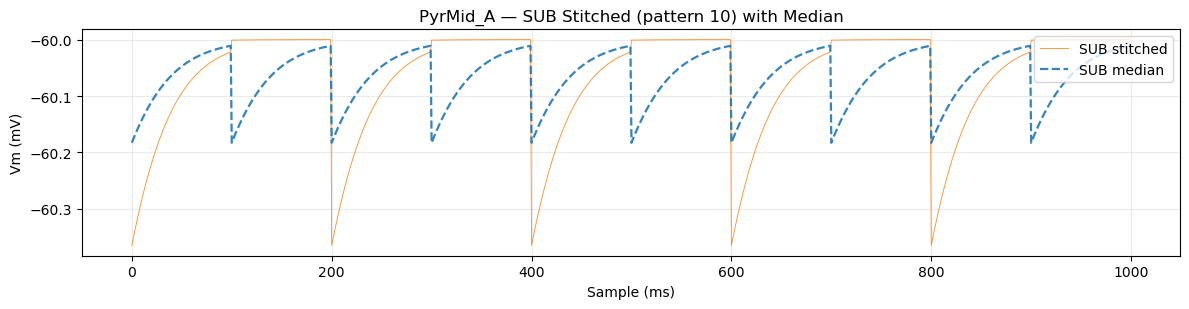

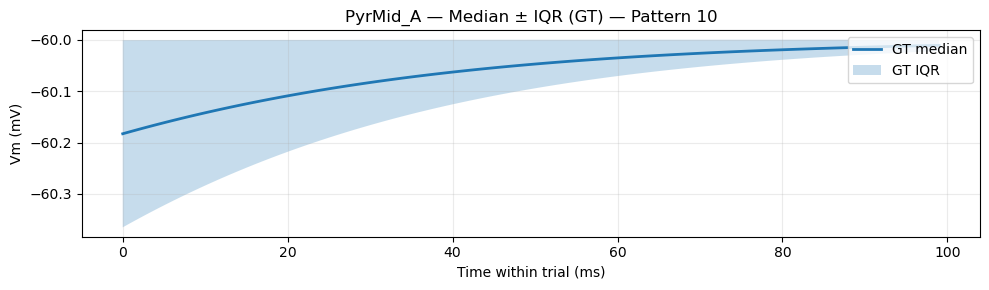

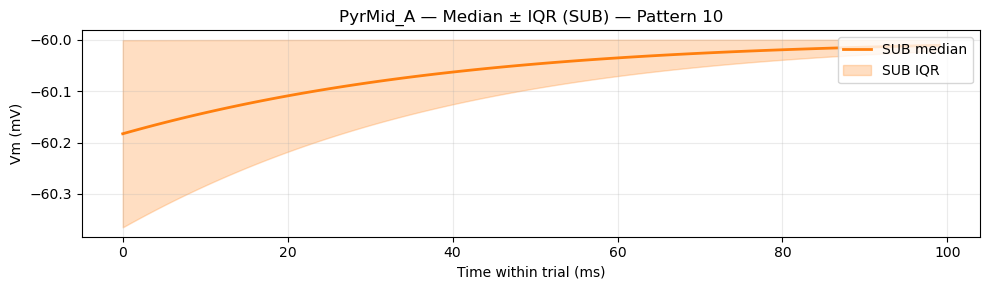

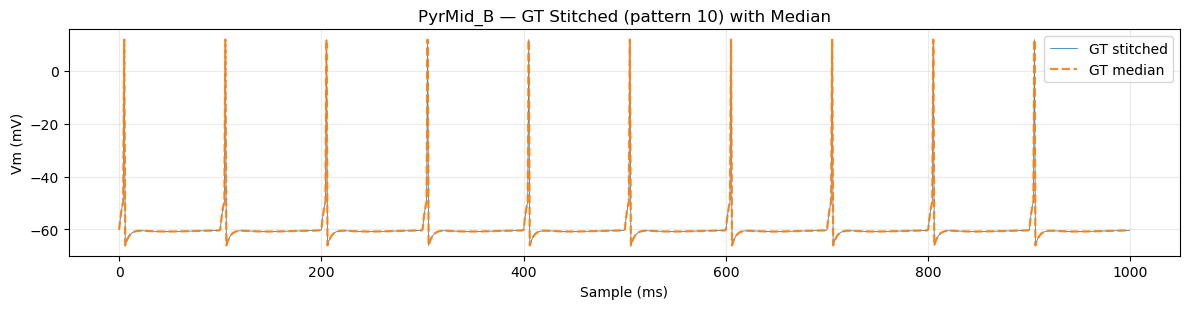

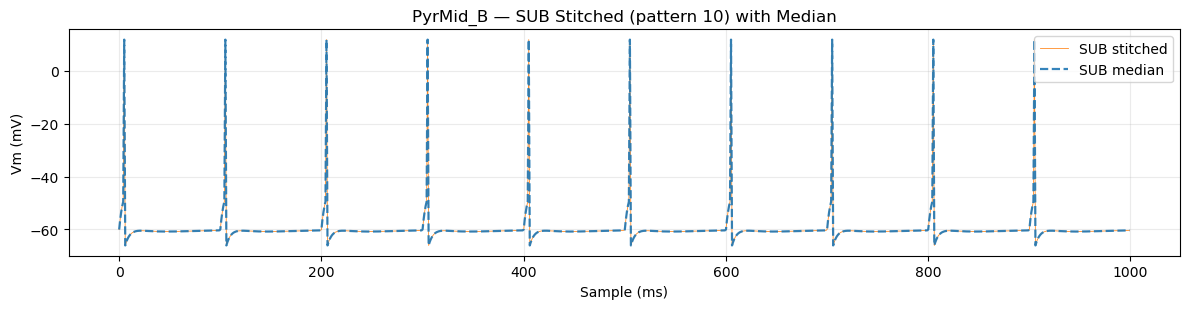

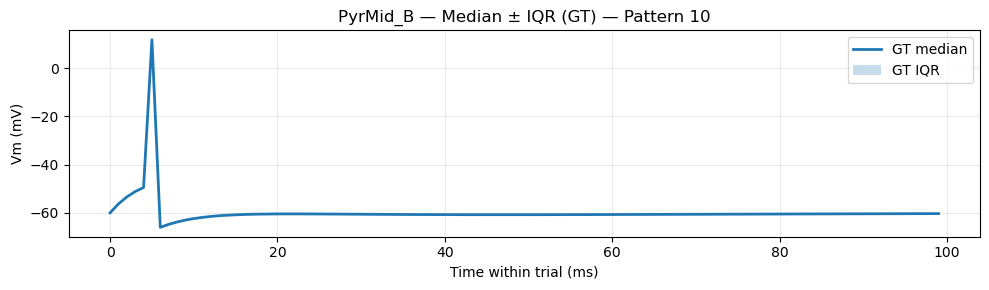

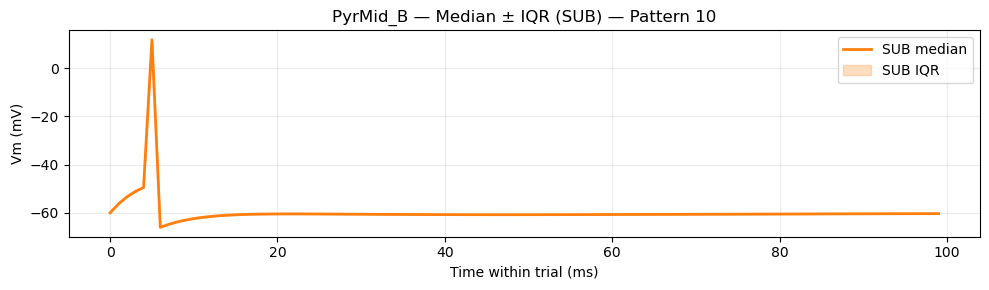

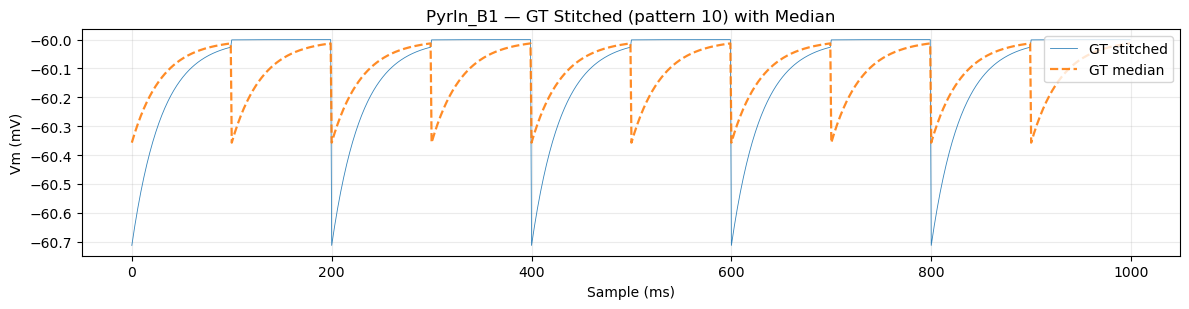

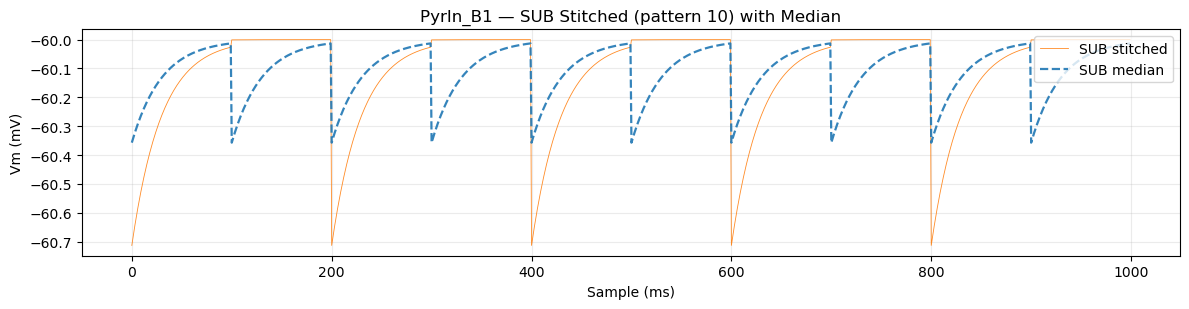

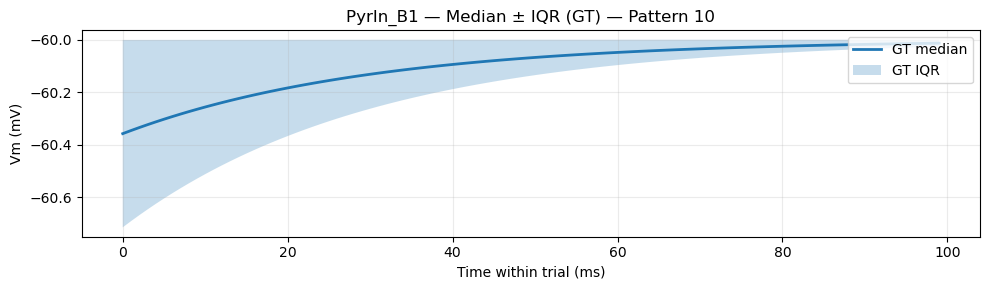

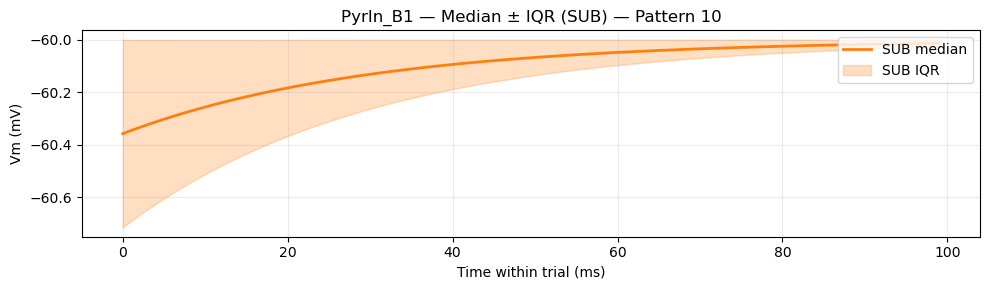

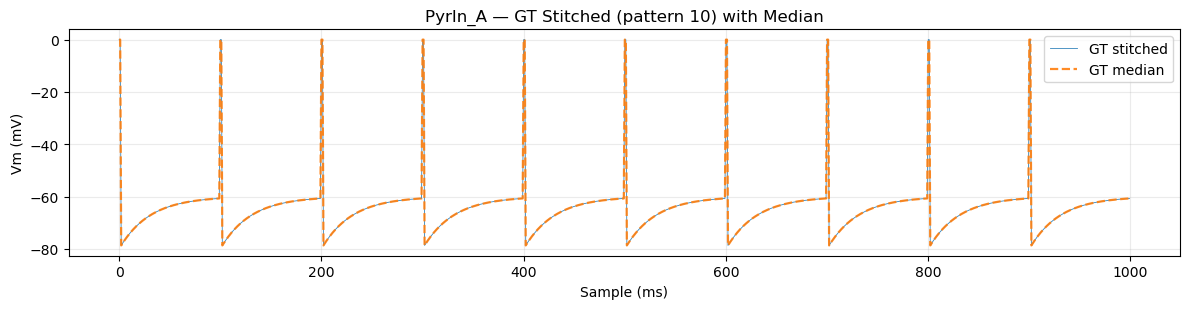

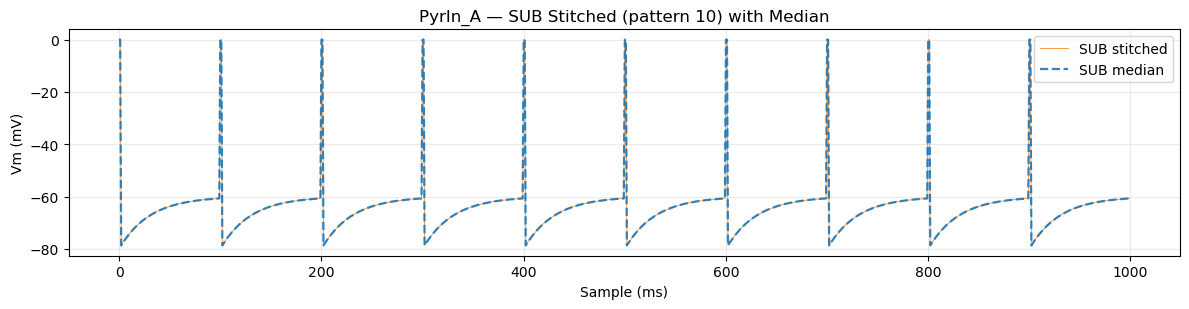

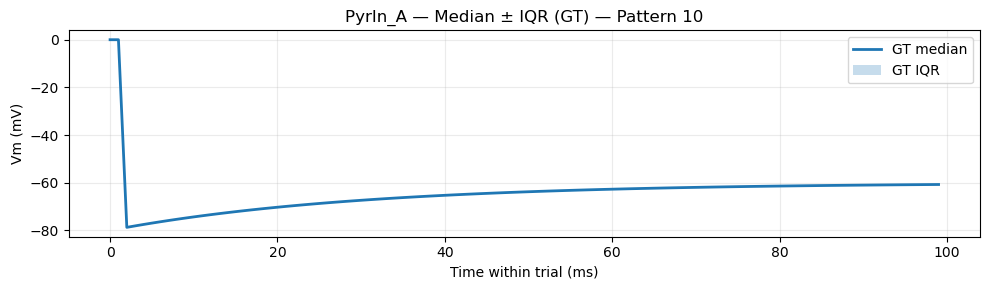

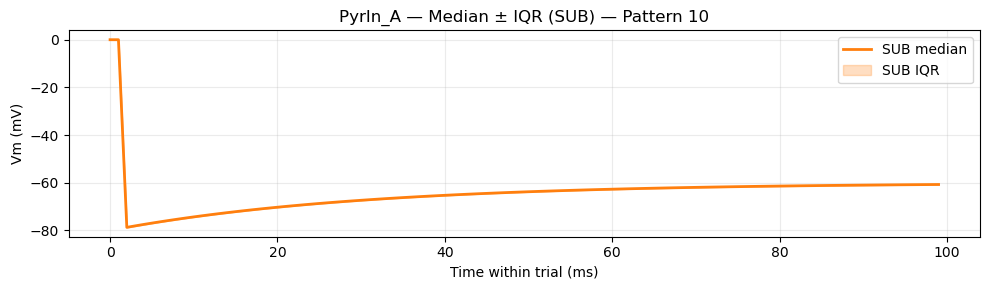

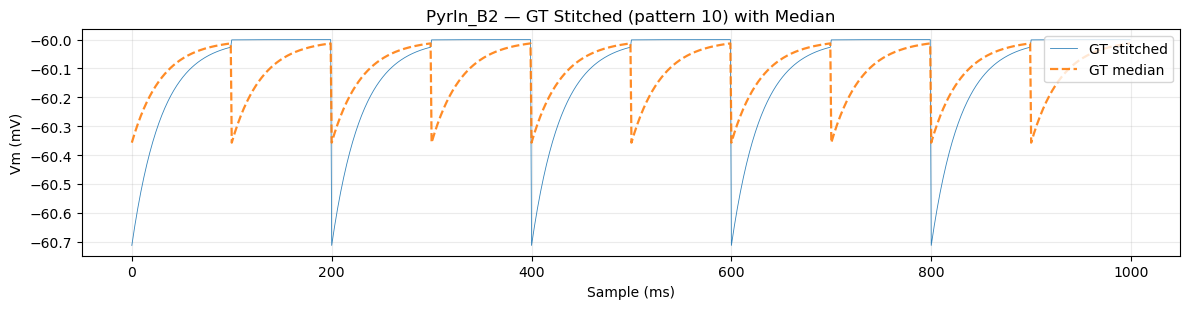

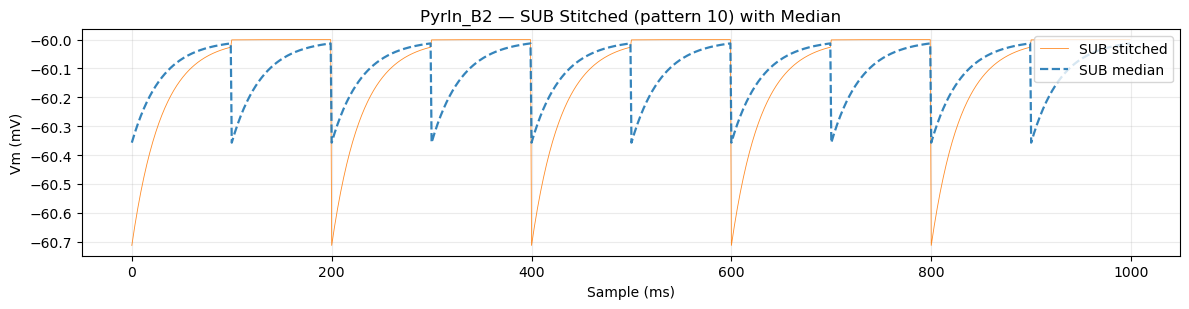

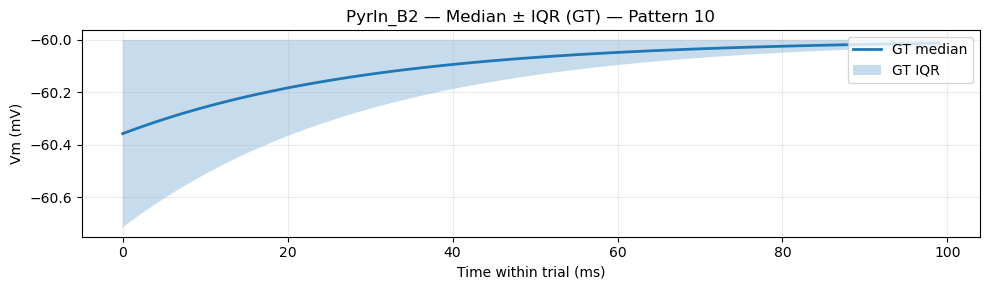

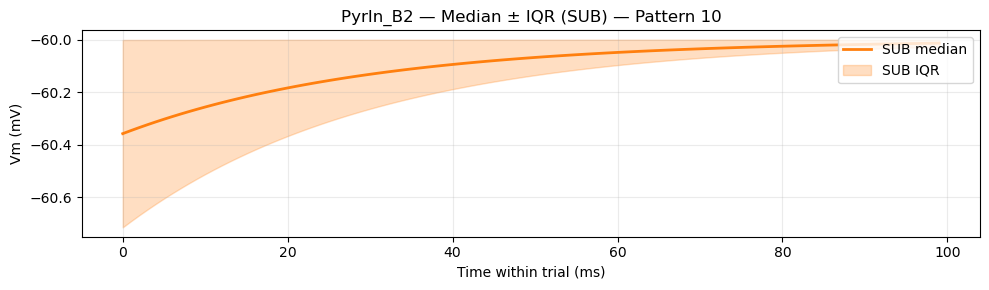

In [3]:
#Membrane Potential Visualization - Stitched Traces and Statistical Views

# Maximum trials to show in stitched view (None = all)
MAX_TRIALS_PER_PATTERN_STITCH = None


#Initializing common stuff that gets repeated
spike_cols = list(set(hp.get_spike_cols(cfg, gt_data)) | set(hp.get_spike_cols(cfg, sub_data)))
patterns = tmap["case"].unique().tolist()
for patt in patterns:
    common_ids = tmap[tmap["case"] == patt]["trial_id"].tolist()


meta = hp.load_metadata(h5_file_path_gt)
trial_len = int(meta["trial_len_ms"])

def _median_iqr_over_trials(trials, idxs, col):
    """
    Compute per-sample median and IQR across trials.
    Returns: (median, q25, q75) arrays of length trial_len
    """
    if not idxs:
        return None, None, None

    mat = []
    for i in idxs:
        if i >= len(trials):
            continue
        vec = trials[i][col].to_numpy(float)
        if len(vec) >= trial_len:
            mat.append(vec[:int(trial_len)])

    if not mat:
        return None, None, None

    M = np.vstack(mat)
    med = np.nanmedian(M, axis=0)
    q25 = np.nanpercentile(M, 25, axis=0)
    q75 = np.nanpercentile(M, 75, axis=0)
    return med, q25, q75

def _stitch_series(trials, idxs, col, max_trials=None):
    """
    Concatenate trials end-to-end.
    Returns: (stitched_y, time_axis)
    """
    if not idxs:
        return np.array([]), np.array([])

    use = idxs if (max_trials is None) else idxs[:max_trials]
    chunks = []
    for i in use:
        vec = trials[i][col].to_numpy(float)[:trial_len]
        chunks.append(vec)

    if not chunks:
        return np.array([]), np.array([])

    y = np.concatenate(chunks)
    t = np.arange(y.size, dtype=float)
    return y, t

def _neuron_label(col):
    """Extract neuron name from column."""
    return col.replace("_vm", "")


# Generate visualizations for each pattern and neuron
print("Membrane Potential Visualization - Stitched Traces and Statistical Views")
for patt in patterns:
    common_ids = tmap[tmap["case"] == patt]["trial_id"].tolist()
    gt_trials_p  = [hp.get_trial(gt_data,  trial_id=i) for i in common_ids]
    sub_trials_p = [hp.get_trial(sub_data, trial_id=i) for i in common_ids]
    print(common_ids)
    for col in hp.get_vm_cols(cfg, scope="active"):
        neuron = _neuron_label(col)

        # Compute statistics
        med_gt, q25_gt, q75_gt = _median_iqr_over_trials(gt_trials_p, range(len(gt_trials_p)), col)
        med_sub, q25_sub, q75_sub = _median_iqr_over_trials(sub_trials_p, range(len(sub_trials_p)), col)

        # Figure 1: GT stitched with median overlay
        y_gt, t_gt = _stitch_series(gt_trials_p, range(len(gt_trials_p)), col, MAX_TRIALS_PER_PATTERN_STITCH)
        fig, ax = plt.subplots(figsize=(12, 3.2))

        if y_gt.size:
            ax.plot(t_gt, y_gt, lw=0.6, label="GT stitched", alpha=0.9)

        if med_gt is not None:
            reps = int(np.ceil(max(1, y_gt.size) / trial_len))
            med_tile = np.tile(med_gt, reps)[:max(1, y_gt.size)]
            ax.plot(np.arange(med_tile.size), med_tile, lw=1.6, linestyle="--",
                   label="GT median", alpha=0.9)

        ax.set_title(f"{neuron} — GT Stitched (pattern {patt}) with Median")
        ax.set_xlabel("Sample (ms)")
        ax.set_ylabel("Vm (mV)")
        ax.grid(alpha=0.25)
        ax.legend(loc="upper right")
        plt.tight_layout()
        plt.show()

        # Figure 2: SUB stitched with median overlay
        y_sub, t_sub = _stitch_series(sub_trials_p, range(len(gt_trials_p)), col, MAX_TRIALS_PER_PATTERN_STITCH)
        fig, ax = plt.subplots(figsize=(12, 3.2))

        if y_sub.size:
            ax.plot(t_sub, y_sub, lw=0.6, color="tab:orange", label="SUB stitched", alpha=0.9)

        if med_sub is not None:
            reps = int(np.ceil(max(1, y_sub.size) / trial_len))
            med_tile = np.tile(med_sub, reps)[:max(1, y_sub.size)]
            ax.plot(np.arange(med_tile.size), med_tile, lw=1.6, linestyle="--",
                   color="tab:blue", label="SUB median", alpha=0.9)

        ax.set_title(f"{neuron} — SUB Stitched (pattern {patt}) with Median")
        ax.set_xlabel("Sample (ms)")
        ax.set_ylabel("Vm (mV)")
        ax.grid(alpha=0.25)
        ax.legend(loc="upper right")
        plt.tight_layout()
        plt.show()

        # Figure 3: GT Median ± IQR
        x = np.arange(trial_len)
        fig, ax = plt.subplots(figsize=(10, 3.0))

        if med_gt is not None:
            ax.plot(x, med_gt, lw=2.0, label="GT median")
            if (q25_gt is not None) and (q75_gt is not None):
                ax.fill_between(x, q25_gt, q75_gt, alpha=0.25, label="GT IQR")

        ax.set_title(f"{neuron} — Median ± IQR (GT) — Pattern {patt}")
        ax.set_xlabel("Time within trial (ms)")
        ax.set_ylabel("Vm (mV)")
        ax.grid(alpha=0.25)
        ax.legend(loc="upper right")
        plt.tight_layout()
        plt.show()

        # Figure 4: SUB Median ± IQR
        fig, ax = plt.subplots(figsize=(10, 3.0))

        if med_sub is not None:
            ax.plot(x, med_sub, lw=2.0, color="tab:orange", label="SUB median")
            if (q25_sub is not None) and (q75_sub is not None):
                ax.fill_between(x, q25_sub, q75_sub, alpha=0.25, color="tab:orange", label="SUB IQR")

        ax.set_title(f"{neuron} — Median ± IQR (SUB) — Pattern {patt}")
        ax.set_xlabel("Time within trial (ms)")
        ax.set_ylabel("Vm (mV)")
        ax.grid(alpha=0.25)
        ax.legend(loc="upper right")
        plt.tight_layout()
        plt.show()


PSTH Metric - Peristimulus Time Histogram Analysis


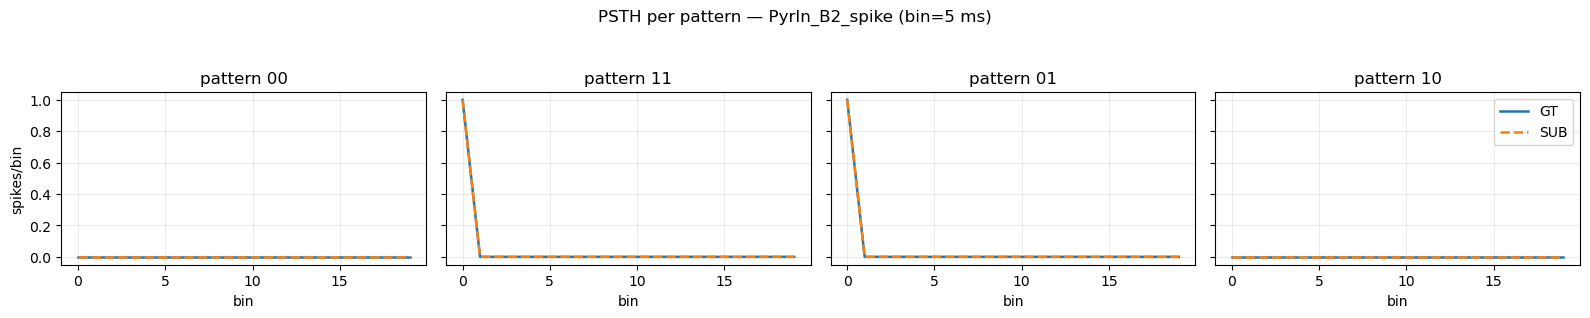

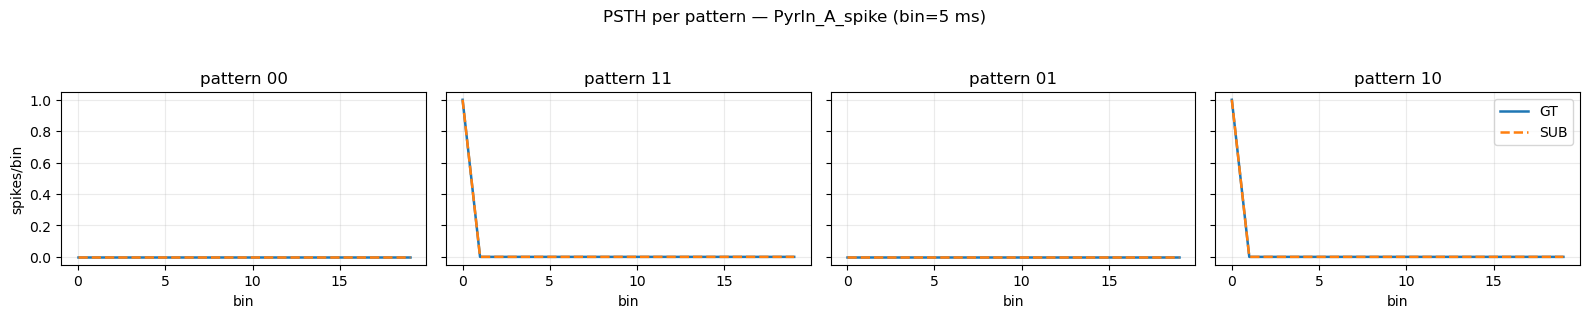

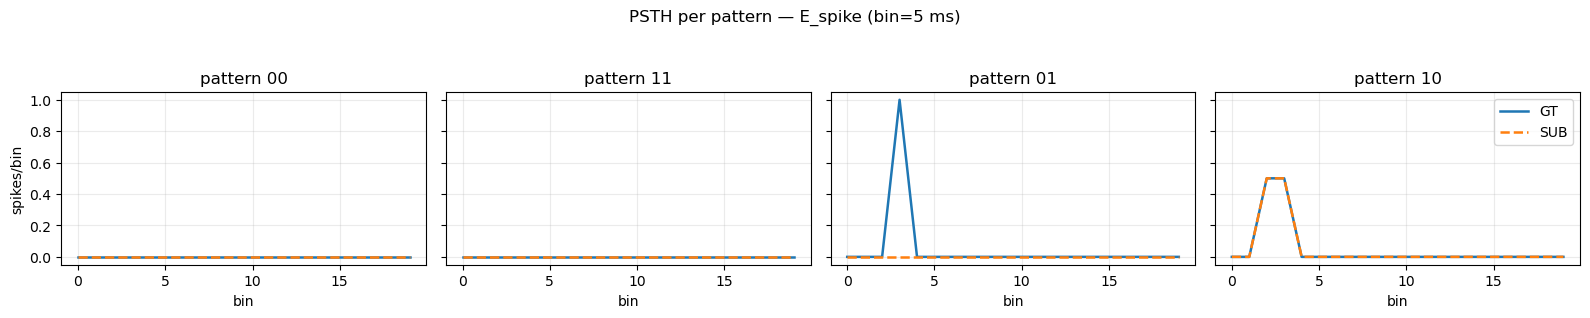

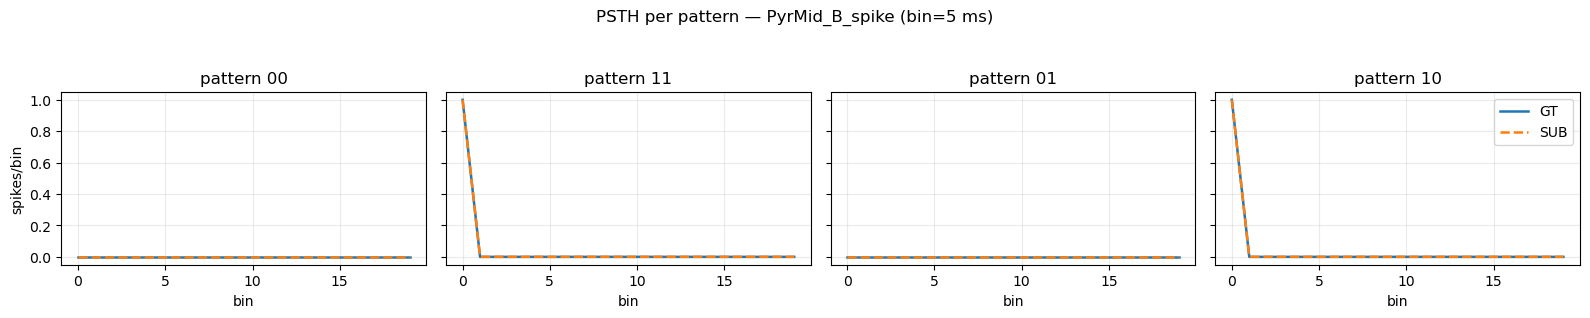

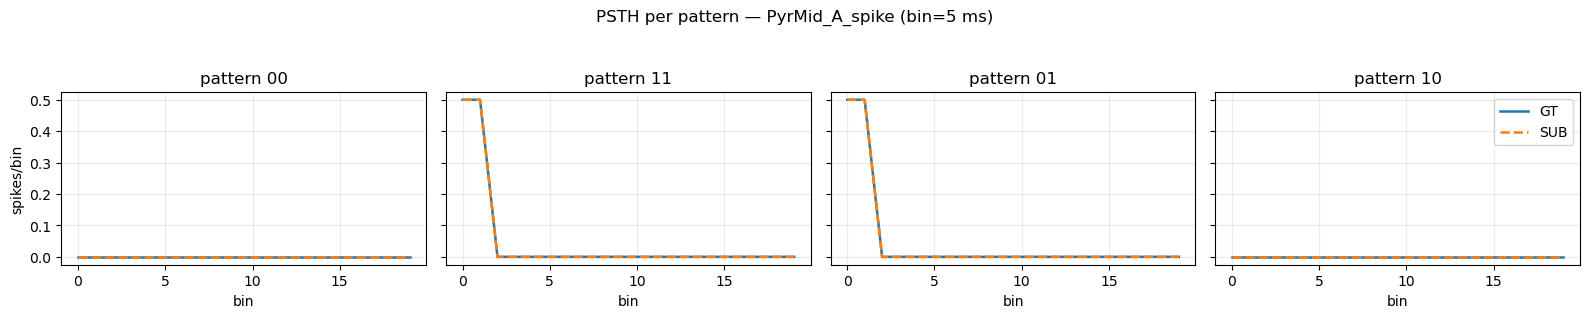

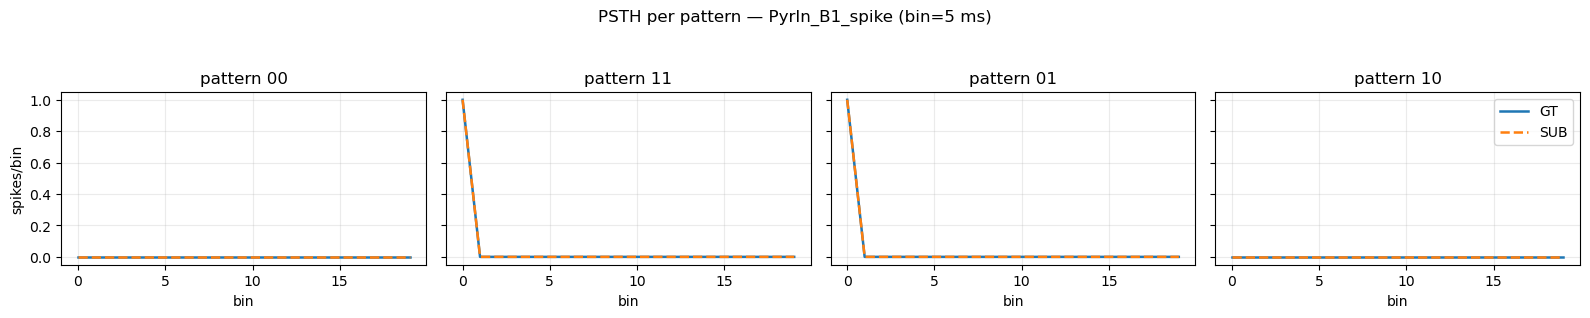

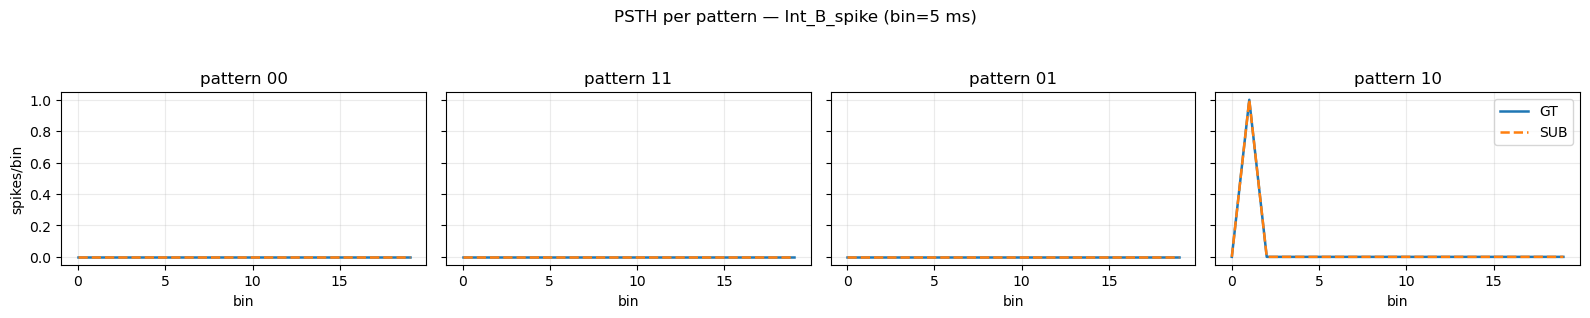

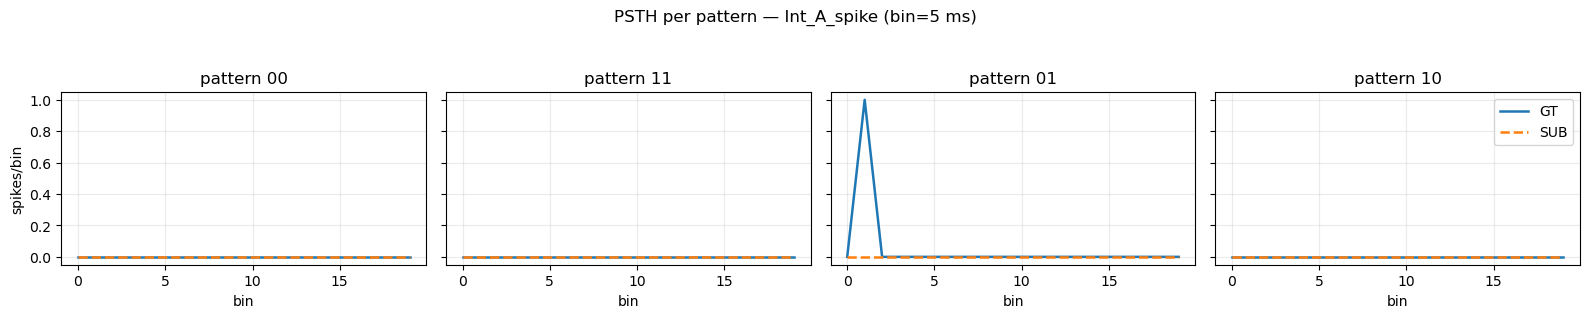

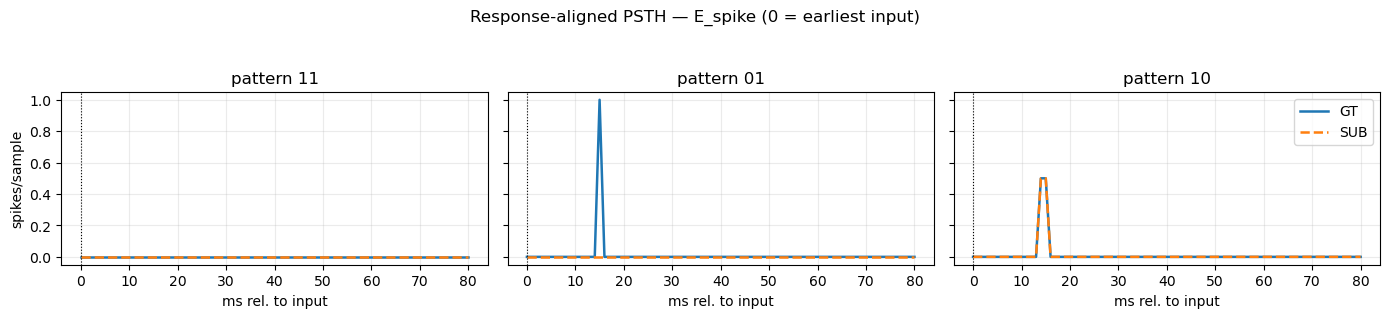

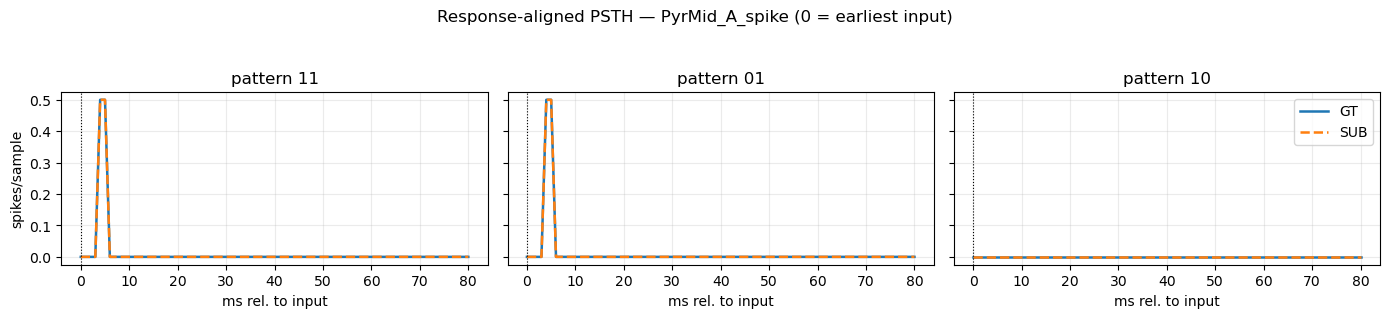

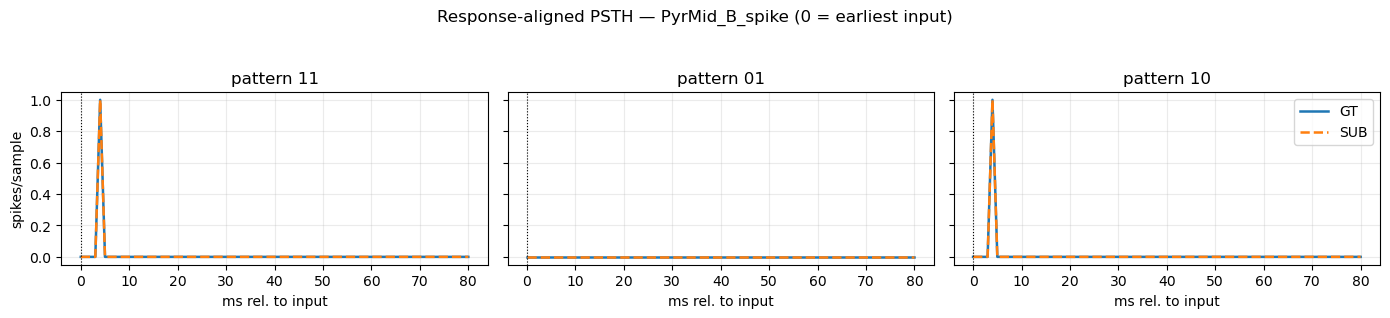


[PSTH metrics] (r, RMSE, bias) per neuron:
        Neuron  Overall_r  Overall_RMSE  Overall_bias(GT-SUB)  r_00  r_11  r_01  r_10  RMSE_00  RMSE_11  RMSE_01  RMSE_10  bias_00  bias_11  bias_01  bias_10
PyrIn_B2_spike      1.000        0.0000                0.0000   NaN   1.0   1.0   NaN      0.0      0.0   0.0000      0.0      0.0      0.0     0.00      0.0
 PyrIn_A_spike      1.000        0.0000                0.0000   NaN   1.0   NaN   1.0      0.0      0.0   0.0000      0.0      0.0      0.0     0.00      0.0
       E_spike      0.565        0.1118                0.0125   NaN   NaN   NaN   1.0      0.0      0.0   0.2236      0.0      0.0      0.0     0.05      0.0
PyrMid_B_spike      1.000        0.0000                0.0000   NaN   1.0   NaN   1.0      0.0      0.0   0.0000      0.0      0.0      0.0     0.00      0.0
PyrMid_A_spike      1.000        0.0000                0.0000   NaN   1.0   1.0   NaN      0.0      0.0   0.0000      0.0      0.0      0.0     0.00      0.0
PyrIn_B1

In [4]:
# PSTH Metric - Peristimulus Time Histogram Analysis

# Configuration
BIN_MS          = 5          # Bin size for PSTH
SMOOTH_FOR_PLOT = False      # Smooth for visualization only
SMOOTH_SIGMA    = 2.0        # Gaussian smoothing sigma (bins)

# Response-aligned window (ms relative to earliest input)
ALIGN_PRE_MS    = 10
ALIGN_POST_MS   = 80

# Thresholds for narrative
SMALL_RMSE      = 0.01
MODERATE_RMSE   = 0.03
HIGH_R_FLOOR    = 0.98
OK_R_FLOOR      = 0.90
LAT_MS_TOL      = 2.0

RESP_ALIGN_PATTERNS = [p for p in patterns
                       if truth_table[f"XOR_{p}"]["input_A"] > 0 
                       or truth_table[f"XOR_{p}"]["input_B"] > 0]
FOCUS_NEURONS = [n + "_spike" for n in hp.get_neurons(cfg, role=["intermediate", "output"])]
SHOW_RATE     = False
RATE_SCALE    = 1000.0 / BIN_MS
LATENCY_METHOD = "com"
COM_FRAC      = 0.30

print("PSTH Metric - Peristimulus Time Histogram Analysis")

def _safe_pearson(a, b):
    """Compute Pearson correlation, handling edge cases."""
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    if a.size != b.size or a.size == 0:
        return np.nan
    va = np.nanvar(a)
    vb = np.nanvar(b)
    if va <= 0 or vb <= 0:
        return np.nan
    am = np.nanmean(a)
    bm = np.nanmean(b)
    num = np.nansum((a - am) * (b - bm))
    den = np.sqrt(np.nansum((a - am)**2) * np.nansum((b - bm)**2))
    return float(num / den) if den > 0 else np.nan

def _rmse(a, b):
    """Compute RMSE between two arrays."""
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    if a.size != b.size or a.size == 0:
        return np.nan
    d = a - b
    return float(np.sqrt(np.nanmean(d*d)))

def _gauss1d(sigma_bins, radius=3):
    """Create 1D Gaussian kernel for smoothing."""
    sig = float(max(1e-9, sigma_bins))
    rad = int(max(1, int(radius * sig)))
    x = np.arange(-rad, rad+1, 1.0)
    k = np.exp(-(x*x)/(2*sig*sig))
    k /= k.sum()
    return k

def _bin_counts(vec, bin_ms, fs):
    """Bin spike vector into counts."""
    x = np.asarray(vec, int)
    bin_size = int(max(1, round((bin_ms/1000.0) * fs)))
    nb = len(x) // bin_size
    if nb == 0:
        return np.zeros(0, float)
    xx = x[: nb*bin_size].reshape(nb, bin_size).sum(axis=1).astype(float)
    return xx


def _psth_per_pattern(data, patterns, col, bin_ms, fs):
    out = {}
    for p in patterns:
        use = tmap[tmap["case"] == p]["trial_id"].tolist()
        mats = []
        for i in use:
            v = hp.get_trial(data, trial_id=i)[col].to_numpy(int)
            mats.append(_bin_counts(v, bin_ms, fs))
        if mats:
            L = min(map(len, mats))
            mats = [m[:L] for m in mats]
            out[p] = np.nanmean(np.stack(mats, axis=0), axis=0)
        else:
            out[p] = None
    return out

def _resp_aligned(trials_p, col, pre_ms, post_ms):
    pre  = int(pre_ms)
    post = int(post_ms)
    rows = []
    for trial_df in trials_p:
        vec = trial_df[col].to_numpy(int)
        s = max(0, 0 - pre)
        e = min(trial_len - 1, 0 + post)
        rows.append(vec[s:e+1].astype(float))
    if rows:
        mean_curve = np.nanmean(np.stack(rows, axis=0), axis=0)
        actual_len = e - s + 1
        t_axis = np.arange(s, s + actual_len, 1)
        return t_axis, mean_curve
    return None

def _latency_peak(t, y):
    """Peak latency (argmax)."""
    if y is None or t is None:
        return None
    y = np.asarray(y, float)
    t = np.asarray(t, float)
    if not np.isfinite(y).any():
        return None
    i = int(np.nanargmax(y))
    return float(t[i])

def _latency_com(t, y, frac=0.30):
    """Center-of-mass latency above fraction of peak."""
    if y is None or t is None:
        return None
    y = np.asarray(y, float)
    t = np.asarray(t, float)
    y = np.where(np.isfinite(y), y, 0.0)
    if y.size == 0 or not np.isfinite(y).any():
        return None
    peak = float(np.nanmax(y))
    thr = frac * peak
    y2 = np.where(y >= thr, y, 0.0)
    s = y2.sum()
    if s <= 0:
        return None
    return float((t * y2).sum() / s)

def _latency(t, y, method="com", frac=0.30):
    """Compute latency using specified method."""
    if method == "com":
        val = _latency_com(t, y, frac=frac)
        return val if val is not None else _latency_peak(t, y)
    else:
        return _latency_peak(t, y)

# Compute PSTHs (trial-paired)
GT_psths = {c: _psth_per_pattern(gt_data, patterns, c, BIN_MS, meta["fs_hz"]) for c in spike_cols}
SB_psths = {c: _psth_per_pattern(sub_data, patterns, c, BIN_MS, meta["fs_hz"]) for c in spike_cols}

# Setup smoothing for plots
if SMOOTH_FOR_PLOT:
    K = _gauss1d(SMOOTH_SIGMA)
    _smooth = lambda y: y if y is None or len(y) == 0 else np.convolve(y, K, mode="same")
else:
    _smooth = lambda y: y

_scale_for_plot = (lambda y: None if y is None else y * RATE_SCALE) if SHOW_RATE else (lambda y: y)
_ylabel = "spikes/s" if SHOW_RATE else "spikes/bin"

# Plot per-pattern PSTHs
for col in spike_cols:
    fig, axes = plt.subplots(1, 4, figsize=(16, 3.2), sharey=True)
    fig.suptitle(f"PSTH per pattern — {col} (bin={BIN_MS} ms)")
    for j, p in enumerate(patterns):
        g = GT_psths[col][p]
        s = SB_psths[col][p]
        ax = axes[j]
        if g is not None:
            ax.plot(_scale_for_plot(_smooth(g)), label="GT", linewidth=1.8)
        if s is not None:
            ax.plot(_scale_for_plot(_smooth(s)), label="SUB", linewidth=1.8, linestyle="--")
        ax.set_title(f"pattern {p}")
        ax.set_xlabel("bin")
        if j == 0:
            ax.set_ylabel(_ylabel)
        ax.grid(alpha=0.25)
    axes[-1].legend(loc="upper right")
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()

# Plot response-aligned PSTHs
for col in FOCUS_NEURONS:
    fig, axes = plt.subplots(1, len(RESP_ALIGN_PATTERNS), figsize=(14, 3.2), sharey=True)
    fig.suptitle(f"Response-aligned PSTH — {col} (0 = earliest input)")
    for j, p in enumerate(RESP_ALIGN_PATTERNS):
        trial_ids    = tmap[tmap["case"] == p]["trial_id"].tolist()
        gt_trials_p  = [hp.get_trial(gt_data,  trial_id=i) for i in trial_ids]
        sub_trials_p = [hp.get_trial(sub_data, trial_id=i) for i in trial_ids]
        GT_resp = _resp_aligned(gt_trials_p, col, ALIGN_PRE_MS, ALIGN_POST_MS)
        SB_resp = _resp_aligned(sub_trials_p, col, ALIGN_PRE_MS, ALIGN_POST_MS)
        ax = axes[j]
        if GT_resp is not None:
            tg, yg = GT_resp
            ax.plot(tg, _scale_for_plot(_smooth(yg)), label="GT", linewidth=1.8)
        if SB_resp is not None:
            ts, ys = SB_resp
            ax.plot(ts, _scale_for_plot(_smooth(ys)), label="SUB", linewidth=1.8, linestyle="--")
        ax.set_title(f"pattern {p}")
        ax.set_xlabel("ms rel. to input")
        if j == 0:
            ax.set_ylabel(_ylabel.replace("/bin","/sample") if not SHOW_RATE else _ylabel)
        ax.axvline(0, color="k", lw=0.8, ls=":")
        ax.grid(alpha=0.25)
    axes[-1].legend(loc="upper right")
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()

# Compute numeric metrics
rows = []
perpat = {}
for col in spike_cols:
    # Overall metrics (concatenate all patterns)
    gt_vecs, sb_vecs = [], []
    for p in patterns:
        g = GT_psths[col][p]
        s = SB_psths[col][p]
        if g is None or s is None:
            continue
        L = min(len(g), len(s))
        gt_vecs.append(g[:L])
        sb_vecs.append(s[:L])

    if gt_vecs and sb_vecs:
        G_all = np.concatenate(gt_vecs)
        S_all = np.concatenate(sb_vecs)
        r_all = _safe_pearson(G_all, S_all)
        rmse_all = _rmse(G_all, S_all)
        bias_all = float(np.nanmean(G_all - S_all))
    else:
        r_all = rmse_all = bias_all = np.nan

    # Per-pattern metrics
    pp = {}
    for p in patterns:
        g = GT_psths[col][p]
        s = SB_psths[col][p]
        if (g is None) or (s is None) or (len(g)==0) or (len(s)==0):
            pp[p] = {"r": np.nan, "rmse": np.nan, "bias": np.nan}
        else:
            L = min(len(g), len(s))
            gg, ss = g[:L], s[:L]
            pp[p] = {
                "r": _safe_pearson(gg, ss),
                "rmse": _rmse(gg, ss),
                "bias": float(np.nanmean(gg - ss))
            }
    perpat[col] = pp

    rows.append({
        "Neuron": col,
        "Overall_r":            r_all,
        "Overall_RMSE":         rmse_all,
        "Overall_bias(GT-SUB)": bias_all,
        **{f"r_{p}":    pp[p]["r"]    for p in patterns},
        **{f"RMSE_{p}": pp[p]["rmse"] for p in patterns},
        **{f"bias_{p}": pp[p]["bias"] for p in patterns},
    })

psth_metrics = pd.DataFrame(rows)
with pd.option_context("display.max_columns", None):
    print("\n[PSTH metrics] (r, RMSE, bias) per neuron:")
    print(psth_metrics.round(4).to_string(index=False))

# Compute latencies for aligned curves
latency = {}
for col in FOCUS_NEURONS:
    lat = {}
    for p in RESP_ALIGN_PATTERNS:
        trial_ids    = tmap[tmap["case"] == p]["trial_id"].tolist()
        gt_trials_p  = [hp.get_trial(gt_data,  trial_id=i) for i in trial_ids]
        sub_trials_p = [hp.get_trial(sub_data, trial_id=i) for i in trial_ids]
        GTa = _resp_aligned(gt_trials_p, col, ALIGN_PRE_MS, ALIGN_POST_MS)
        SBa = _resp_aligned(sub_trials_p, col, ALIGN_PRE_MS, ALIGN_POST_MS)
        if GTa is None or SBa is None:
            lat[p] = np.nan
        else:
            tg, yg = GTa
            ts, ys = SBa
            lg = _latency(tg, yg, method=LATENCY_METHOD, frac=COM_FRAC)
            ls = _latency(ts, ys, method=LATENCY_METHOD, frac=COM_FRAC)
            lat[p] = np.nan if (lg is None or ls is None) else float(ls - lg)
    latency[col] = lat

# Generate narrative
def f3(x):
    """Format to 3 decimal places."""
    return "n/a" if not np.isfinite(x) else f"{x:.3f}"

def f3_signed(x):
    """Format with sign."""
    return "" if not np.isfinite(x) else f" ({x:+.3f})"

def bias_word(b):
    """Describe bias direction."""
    if not np.isfinite(b) or abs(b) < 1e-6:
        return "no bias"
    return "GT higher" if b > 0 else "SUB higher"

bullets = []

# Overall health per neuron
for _, row in psth_metrics.iterrows():
    n = row["Neuron"]
    r = row["Overall_r"]
    rm = row["Overall_RMSE"]
    b = row["Overall_bias(GT-SUB)"]
    grade = ("excellent" if (np.isfinite(r) and r >= HIGH_R_FLOOR)
             else "good" if (np.isfinite(r) and r >= OK_R_FLOOR)
             else "weak" if np.isfinite(r) else "n/a")
    bullets.append(
        f"{n}: shape {grade} (r={f3(r)}), "
        f"level mismatch RMSE={f3(rm)} spikes/bin, "
        f"bias={bias_word(b)}{f3_signed(b)}."
    )

# Worst pattern per neuron
for col in spike_cols:
    stats = perpat[col]
    rmse_vals = {p: (stats[p]['rmse'] if np.isfinite(stats[p]['rmse']) else -1) for p in patterns}
    worst = max(rmse_vals, key=rmse_vals.get)
    wv = stats[worst]
    if np.isfinite(wv["rmse"]) and wv["rmse"] > SMALL_RMSE:
        bias_txt = f3_signed(wv['bias']).strip() or '0.000'
        bullets.append(
            f"{col}: largest difference in pattern {worst} "
            f"(r={f3(wv['r'])}, RMSE={f3(wv['rmse'])}, bias={bias_txt})."
        )

# Latency differences
for col in FOCUS_NEURONS:
    for p in RESP_ALIGN_PATTERNS:
        dlat = latency[col][p]
        if np.isfinite(dlat) and abs(dlat) > LAT_MS_TOL:
            direction = "SUB earlier" if dlat < 0 else "SUB later"
            bullets.append(f"{col}@{p}: {direction} by ~{dlat:.1f} ms (latency).")

# Summary
output_neuron = hp.get_neurons(cfg, role="output")[0] + "_spike"
worst_pattern = tmap[tmap["case"].isin(["00","11"])]["case"].unique()[0]
e11 = perpat[output_neuron][worst_pattern]

print("\n=== PSTH Auto-Narrative ===")
for b in bullets:
    print("•", b)

# Bundle results
PSTH_RESULTS = dict(
    bin_ms=BIN_MS,
    fs_hz=meta["fs_hz"],
    patterns=patterns,
    gt_psths=GT_psths,
    sub_psths=SB_psths,
    metrics=psth_metrics,
    latency=latency,
    config=dict(
        SMOOTH_FOR_PLOT=SMOOTH_FOR_PLOT, SMOOTH_SIGMA=SMOOTH_SIGMA,
        SHOW_RATE=SHOW_RATE, LATENCY_METHOD=LATENCY_METHOD, COM_FRAC=COM_FRAC
    )
)
AUTO_PSTH_REPORT = dict(
    psth_summary=psth_metrics,
    per_pattern=perpat,
    latency=latency,
    bullets=bullets,
    config=dict(BIN_MS=BIN_MS, ALIGN_PRE_MS=ALIGN_PRE_MS, ALIGN_POST_MS=ALIGN_POST_MS)
)
print("[PSTH] Results bundled: PSTH_RESULTS, AUTO_PSTH_REPORT")


In [5]:
# PSP Counts Metric - Peak detection in membrane potentials
from scipy.signal import find_peaks

# Detection parameters
PEAK_PROMINENCE = 0.5        # mV threshold for PSP detection
MIN_PEAK_DISTANCE_MS = 2     # Minimum distance between peaks
BASELINE_PRE_MS = 10         # Baseline window before input
CLIP_TO_RESP_WINDOW = True   # Count only within response window

print("PSP Counts Metric - Peak detection in membrane potentials")

def _earliest_anchor(m):
    """Get earliest input time."""
    a, b = m.get("a_time"), m.get("b_time")
    if a is None and b is None:
        return None
    return min([t for t in (a, b) if t is not None])

def _baseline_subtracted(vec, pre_ms=BASELINE_PRE_MS):
    v = np.asarray(vec, float)
    # anchor is always 0 — baseline is pre_ms before stimulus
    s, e = 0, min(int(trial_len) - 1, int(pre_ms))
    base = float(np.nanmedian(v[s:e+1]))
    return v - base

def _detect_psp_counts(v0, lo, hi):
    """Detect EPSP and IPSP peaks in window."""
    v = np.asarray(v0, float)
    use_lo = int(max(0, lo)) if CLIP_TO_RESP_WINDOW else 0
    use_hi = int(min(len(v)-1, hi)) if CLIP_TO_RESP_WINDOW else len(v)-1

    if use_hi < use_lo:
        return 0, 0

    seg = v[use_lo:use_hi+1]
    p_up, _ = find_peaks(seg, prominence=PEAK_PROMINENCE, distance=max(1, int(MIN_PEAK_DISTANCE_MS)))
    p_down, _ = find_peaks(-seg, prominence=PEAK_PROMINENCE, distance=max(1, int(MIN_PEAK_DISTANCE_MS)))

    return int(p_up.size), int(p_down.size)

# Build counts table
vm_cols = hp.get_vm_cols(cfg, scope="all")
rows_counts = []
for patt in patterns:
    ids = tmap[tmap["case"] == patt]["trial_id"].tolist()
    if not ids:
        continue

    for col in vm_cols:  # ← also fix this — see point 3
        epsp_gt = ipsp_gt = epsp_sb = ipsp_sb = 0

        for i in ids:
            gt_df = hp.get_trial(gt_data, trial_id=i)
            sb_df = hp.get_trial(sub_data, trial_id=i)
            lo, hi = 0, int(trial_len)

            vbs  = _baseline_subtracted(gt_df[col].to_numpy(float))
            n_up, n_dn = _detect_psp_counts(vbs, lo, hi)
            epsp_gt += n_up
            ipsp_gt += n_dn

            vbs2 = _baseline_subtracted(sb_df[col].to_numpy(float))
            n_up2, n_dn2 = _detect_psp_counts(vbs2, lo, hi)
            epsp_sb += n_up2
            ipsp_sb += n_dn2

        rows_counts.append(dict(
            pattern=patt,
            neuron=col.replace("_vm", ""),
            n_trials=len(ids),
            EPSP_GT=epsp_gt, EPSP_SUB=epsp_sb,
            IPSP_GT=ipsp_gt, IPSP_SUB=ipsp_sb
        ))

PSP_COUNTS = pd.DataFrame(rows_counts).sort_values(["pattern", "neuron"]).reset_index(drop=True)

# Print formatted table
def print_psp_counts_by_pattern(df):
    """Display PSP counts with pattern separators."""
    df = df.sort_values(["pattern", "neuron", "n_trials"]).reset_index(drop=True)
    pat_groups = list(df.groupby("pattern", sort=False))

    header_cols = ["pattern", "neuron", "n_trials", "EPSP_GT", "EPSP_SUB", "IPSP_GT", "IPSP_SUB"]
    header = " ".join(f"{c:>12}" if c != "neuron" else f"{c:>8}" for c in header_cols)
    sep = "-" * max(88, len(header))

    print("\n=== PSP — Counts (GT vs SUB, per pattern × neuron) ===")
    print(header)
    print(sep)

    for idx, (patt, g) in enumerate(pat_groups):
        for _, r in g[header_cols].iterrows():
            print(f"{str(r['pattern']):>12} "
                  f"{str(r['neuron']):>8} "
                  f"{int(r['n_trials']):>12d} "
                  f"{int(r['EPSP_GT']):>12d} {int(r['EPSP_SUB']):>11d} "
                  f"{int(r['IPSP_GT']):>12d} {int(r['IPSP_SUB']):>11d}")
        if idx < len(pat_groups) - 1:
            print(sep)

print_psp_counts_by_pattern(PSP_COUNTS)


PSP Counts Metric - Peak detection in membrane potentials

=== PSP — Counts (GT vs SUB, per pattern × neuron) ===
     pattern   neuron     n_trials      EPSP_GT     EPSP_SUB      IPSP_GT     IPSP_SUB
----------------------------------------------------------------------------------------
          00        E           10            0           0            0           0
          00    Int_A           10            0           0            0           0
          00    Int_B           10            0           0            0           0
          00  PyrIn_A           10            0           0            0           0
          00 PyrIn_B1           10            0           0            0           0
          00 PyrIn_B2           10            0           0            0           0
          00 PyrMid_A           10            0           0            0           0
          00 PyrMid_B           10            0           0            0           0
          00 neuron_0         

Granger Causality Metric - Directional connectivity analysis

=== Granger Causality — Pattern summary (q≤0.05) ===
pattern  edges_GT  edges_SUB  overlap  jaccard
     00         5          5        5      1.0
     11         5          5        5      1.0
     01         5          5        5      1.0
     10         5          5        5      1.0


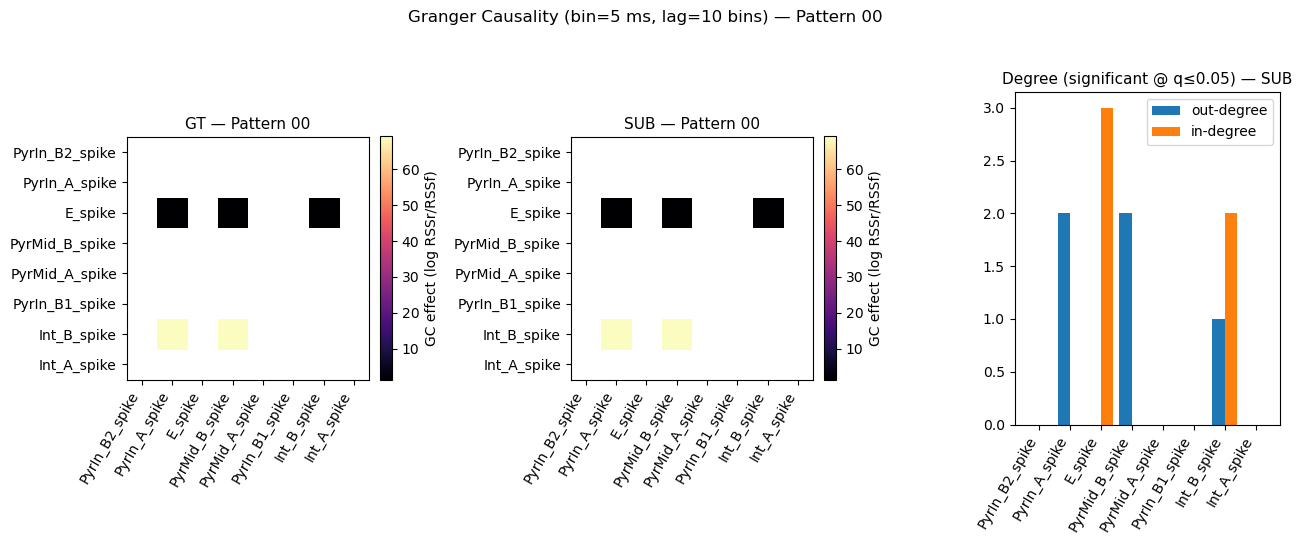

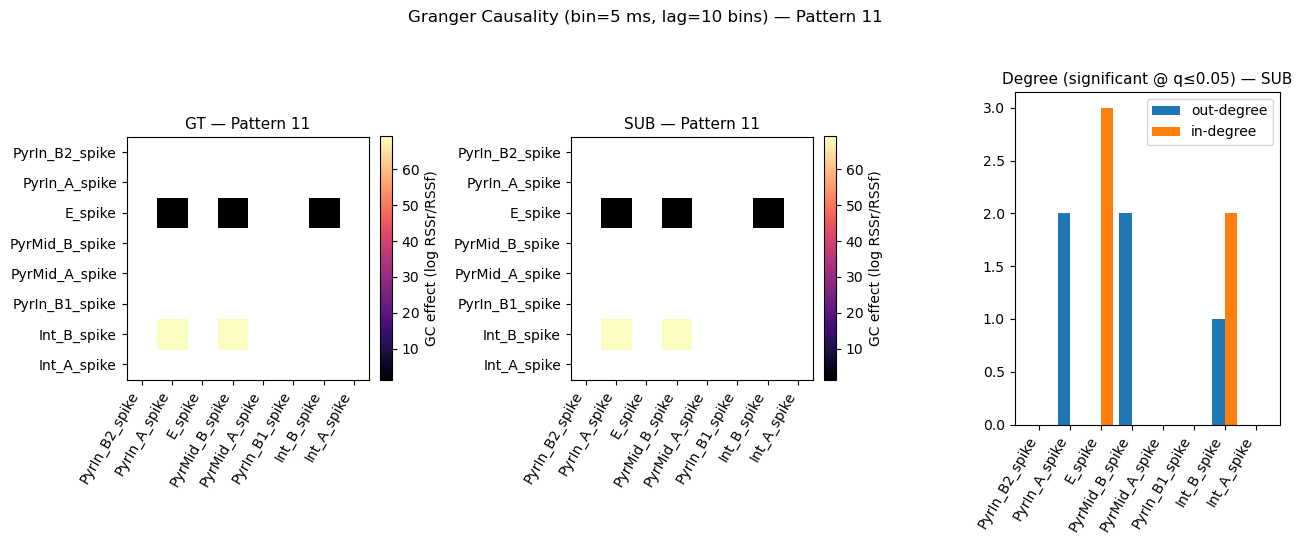

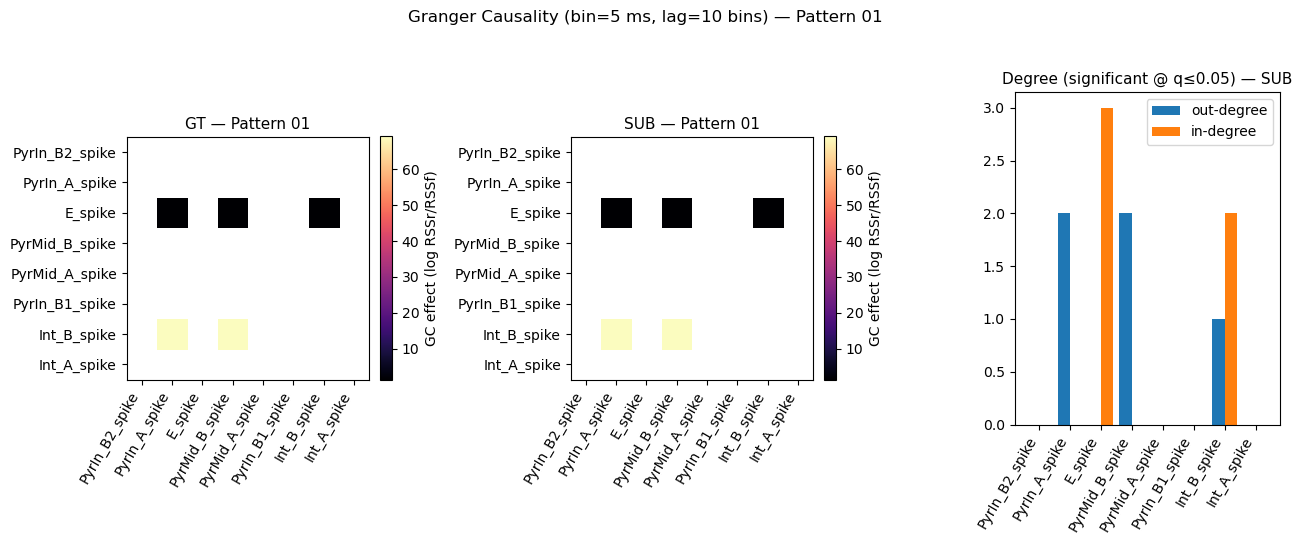

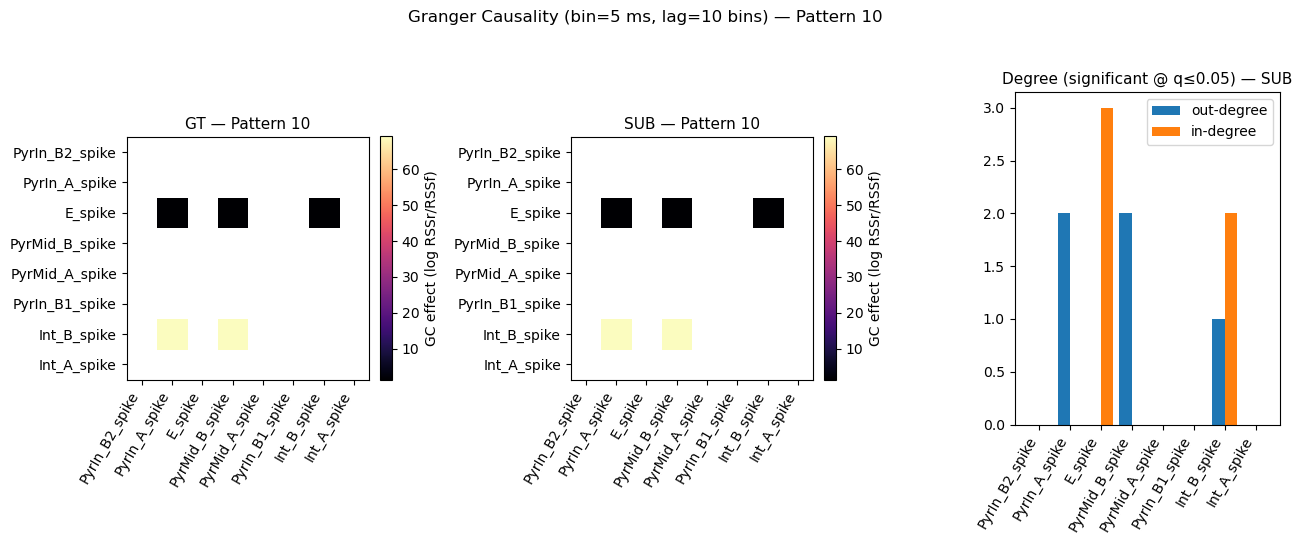

In [6]:
# Granger Causality Metric - Directional connectivity analysis

print("Granger Causality Metric - Directional connectivity analysis")

MS_PER_SAMPLE = 1000.0 / meta["fs_hz"]
# Check for SciPy (needed for p-values)
try:
    from scipy.stats import f as _f_dist
    _HAS_SCIPY = True
except:
    _HAS_SCIPY = False

def _bin_spikes_block(trials, spike_cols, bin_ms=5):
    """Bin and concatenate spike counts across trials."""
    if not trials or not spike_cols:
        return np.zeros((0, 0)), np.array([])

    pieces = []
    for df in trials:
        lo_ms, hi_ms = 0, trial_len
        mask = (df["t_in_trial"] >= lo_ms) & (df["t_in_trial"] < hi_ms)
        if not mask.any():
            continue
        block = df.loc[mask, spike_cols].to_numpy(int)

        # Bin the data
        W = block.shape[0]

        step_ms = MS_PER_SAMPLE
        B = int(np.ceil(W * step_ms / bin_ms))
        binned = np.zeros((B, block.shape[1]), dtype=float)
        for b in range(B):
            lo = int(round((b * bin_ms) / step_ms))
            hi = int(round(((b+1) * bin_ms) / step_ms))
            hi = min(hi, W)
            if lo < hi:
                binned[b] = block[lo:hi].sum(axis=0)
        pieces.append(binned)

    if not pieces:
        return np.zeros((0, len(spike_cols))), np.array([])
    X = np.vstack(pieces)
    edges_ms = np.arange(X.shape[0] + 1) * bin_ms
    return X, edges_ms

def _lag_design(y, X_lags, lag):
    """Build regression design matrices for Granger test."""
    T = y.shape[0]
    if T <= lag:
        return np.zeros(0), np.zeros((0, lag + 1)), np.zeros((0, 2*lag + 1))
    rows = T - lag
    Y = y[lag:]

    def _lags(v):
        return np.column_stack([v[lag - k - 1:T - k - 1] for k in range(lag)])

    Ylags = _lags(y)
    Xlags = _lags(X_lags)
    R = np.column_stack([np.ones(rows), Ylags])
    F = np.column_stack([R, Xlags])
    return Y, R, F

def _ols_rss(design, target):
    """Compute residual sum of squares."""
    if design.shape[0] == 0 or design.shape[1] == 0:
        return np.nan
    beta, *_ = np.linalg.lstsq(design, target, rcond=None)
    resid = target - design @ beta
    return float(np.dot(resid, resid))

def _granger_pair(y, x, lag):
    """Compute Granger causality effect and p-value."""
    Y, R, F = _lag_design(y, x, lag)
    if Y.size == 0:
        return dict(effect=np.nan, p=np.nan)

    rss_r = _ols_rss(R, Y)
    rss_f = _ols_rss(F, Y)
    if not np.isfinite(rss_r) or not np.isfinite(rss_f) or rss_f <= 0:
        return dict(effect=np.nan, p=np.nan)

    effect = np.log(rss_r / rss_f)

    if _HAS_SCIPY:
        df1 = F.shape[1] - R.shape[1]
        df2 = F.shape[0] - F.shape[1]
        if df1 > 0 and df2 > 0:
            Fstat = ((rss_r - rss_f) / df1) / (rss_f / df2)
            p = _f_dist.sf(Fstat, df1, df2)
        else:
            p = np.nan
    else:
        p = np.nan

    return dict(effect=float(effect), p=float(p) if np.isfinite(p) else np.nan)

def _bh_fdr(pvals, alpha=0.05):
    """Benjamini-Hochberg FDR correction."""
    p = np.asarray(pvals, float)
    m = np.sum(np.isfinite(p))
    if m == 0:
        return np.full_like(p, np.nan)

    order = np.argsort(np.where(np.isfinite(p), p, np.inf))
    ranks = np.empty_like(order)
    ranks[order] = np.arange(1, len(p) + 1)
    q = np.full_like(p, np.nan)
    q_work = np.where(np.isfinite(p), p * m / ranks, np.nan)

    # Enforce monotonicity
    prev = np.inf
    for idx in order[::-1]:
        if np.isfinite(q_work[idx]):
            prev = min(prev, q_work[idx])
            q[idx] = prev
    return q

def _gc_for_dataset(trials, spike_cols, bin_ms=5, lag_bins=10, alpha=0.05, min_bins=50, min_spike_sum=10):
    """Compute Granger causality adjacency matrix."""
    X, _ = _bin_spikes_block(trials, spike_cols, bin_ms=bin_ms)
    N = len(spike_cols)
    if X.shape[0] < max(min_bins, lag_bins + 5):
        return (np.full((N, N), np.nan),) * 3 + (np.zeros((N, N), bool),)

    spike_sums = X.sum(axis=0)
    ok_neuron = spike_sums >= min_spike_sum

    # Z-score normalization
    Xz = X.copy().astype(float)
    for j in range(N):
        if ok_neuron[j]:
            mu = Xz[:, j].mean()
            sd = Xz[:, j].std(ddof=1)
            Xz[:, j] = (Xz[:, j] - mu) / (sd if sd > 0 else 1.0)
        else:
            Xz[:, j] = 0.0

    M_eff = np.full((N, N), np.nan)
    M_p = np.full((N, N), np.nan)

    for j in range(N):  # Target
        y = Xz[:, j]
        if not ok_neuron[j]:
            continue
        for i in range(N):  # Source
            if i == j or not ok_neuron[i]:
                continue
            res = _granger_pair(y, Xz[:, i], lag_bins)
            M_eff[j, i] = res["effect"]
            M_p[j, i] = res["p"]

    # FDR correction
    q = _bh_fdr(M_p.ravel(), alpha=alpha).reshape(M_p.shape)
    usable = np.isfinite(M_eff) & np.isfinite(q) & (q <= alpha)
    return M_eff, M_p, q, usable

def run_granger_per_pattern(bin_ms=5, lag_bins=10, alpha=0.05):
    """Run Granger causality analysis per pattern."""
    if not gt_trials_p or not sub_trials_p or not spike_cols:
        return pd.DataFrame(columns=["pattern", "edges_GT", "edges_SUB", "overlap", "jaccard"]), {}

    figs = {}
    rows = []

    for patt in patterns:
        ids = common_ids
        if not ids:
            continue

        gt_tr = [hp.get_trial(gt_data,  trial_id=i) for i in ids]
        sb_tr = [hp.get_trial(sub_data, trial_id=i) for i in ids]


        eff_gt, p_gt, q_gt, use_gt = _gc_for_dataset(gt_tr, spike_cols, bin_ms=bin_ms, lag_bins=lag_bins, alpha=alpha)
        eff_sb, p_sb, q_sb, use_sb = _gc_for_dataset(sb_tr, spike_cols, bin_ms=bin_ms, lag_bins=lag_bins, alpha=alpha)

        # Edge statistics
        A = use_gt
        B = use_sb
        e_gt = int(A.sum() - np.trace(A))
        e_sb = int(B.sum() - np.trace(B))
        inter = int((A & B).sum() - np.trace(A & B))
        union = int((A | B).sum() - np.trace(A | B))
        jacc = (inter / union) if union > 0 else np.nan
        rows.append(dict(pattern=patt, edges_GT=e_gt, edges_SUB=e_sb, overlap=inter, jaccard=jacc))

        # Create figure
        def _plot_heat(ax, M, mask, title):
            im = ax.imshow(np.where(mask, M, np.nan), cmap="magma", aspect="equal")
            ax.set_title(title, fontsize=11)
            ax.set_xticks(np.arange(len(spike_cols)))
            ax.set_xticklabels(spike_cols, rotation=60, ha="right")
            ax.set_yticks(np.arange(len(spike_cols)))
            ax.set_yticklabels(spike_cols)
            cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
            cb.set_label("GC effect (log RSSr/RSSf)")

        def _plot_degree(ax, mask, title):
            outdeg = mask.sum(axis=0)
            indeg = mask.sum(axis=1)
            x = np.arange(len(spike_cols))
            ax.bar(x - 0.2, outdeg, width=0.4, label="out-degree")
            ax.bar(x + 0.2, indeg, width=0.4, label="in-degree")
            ax.set_xticks(x)
            ax.set_xticklabels(spike_cols, rotation=60, ha="right")
            ax.set_title(title, fontsize=11)
            ax.legend()

        fig = plt.figure(figsize=(13, 5.5))
        gs = fig.add_gridspec(2, 3, height_ratios=[1, 1])
        ax1 = fig.add_subplot(gs[:, 0])
        ax2 = fig.add_subplot(gs[:, 1])
        ax3 = fig.add_subplot(gs[:, 2])

        _plot_heat(ax1, eff_gt, use_gt, f"GT — Pattern {patt}")
        _plot_heat(ax2, eff_sb, use_sb, f"SUB — Pattern {patt}")
        _plot_degree(ax3, use_sb, f"Degree (significant @ q≤{alpha}) — SUB")

        fig.suptitle(f"Granger Causality (bin={bin_ms} ms, lag={lag_bins} bins) — Pattern {patt}", fontsize=12)
        fig.tight_layout(rect=[0, 0, 1, 0.95])
        figs[patt] = fig

    summary = pd.DataFrame(rows, columns=["pattern", "edges_GT", "edges_SUB", "overlap", "jaccard"])
    return summary, figs

# Run Granger analysis
gc_summary, gc_figs = run_granger_per_pattern(bin_ms=5, lag_bins=10, alpha=0.05)

if not gc_summary.empty:
    print("\n=== Granger Causality — Pattern summary (q≤0.05) ===")
    print(gc_summary.to_string(index=False))
else:
    print("\n=== Granger Causality — Pattern summary (q≤0.05) ===\n(no patterns)")

for patt, fig in gc_figs.items():
    plt.show(fig)
